# Tanaos Topic Classification

## Imports

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score, f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import Normalizer
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import gensim.downloader as api
from gensim.models import KeyedVectors
import os
from scipy.special import softmax


from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.sparse import hstack

from empath import Empath

## Load Dataset

In [2]:
df = pd.read_csv("data/train_data.csv")

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (10232, 2)

Columns:
['text', 'labels']

Data types:
text      object
labels     int64
dtype: object

Missing values:
text      0
labels    0
dtype: int64


In [4]:
df.head()

,text,labels
0,The rise of populist movements has reshaped gl...,0
1,A balanced diet rich in fruits and vegetables ...,1
2,Quantum cryptography is revolutionizing secure...,2
3,Streaming platforms have transformed how audie...,3
4,Crypto investors are diversifying portfolios a...,4


In [5]:
topics = ["politics","health","technology","entertainment","money_finance","relationships_dating","education_learning","work_careers","science","society_culture","gaming","lifestyle_hobbies","sports","automotive","other"]

### Label Mapping

The dataset stores class labels numerically, so we define a dictionary that maps each numeric label to its corresponding topic name.

In [6]:
topic_dict = dict(enumerate(topics))
print(topic_dict)

{0: 'politics', 1: 'health', 2: 'technology', 3: 'entertainment', 4: 'money_finance', 5: 'relationships_dating', 6: 'education_learning', 7: 'work_careers', 8: 'science', 9: 'society_culture', 10: 'gaming', 11: 'lifestyle_hobbies', 12: 'sports', 13: 'automotive', 14: 'other'}


In [7]:
print("Columns:", df.columns.tolist())
print("Unique labels:", sorted(df["labels"].unique()))
print("Number of classes:", df["labels"].nunique())

Columns: ['text', 'labels']
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Number of classes: 15


### Load Embeddings

In [8]:
model_path = "model/word2vec-google-news-300.kv"

folder_name = os.path.dirname(model_path)
if folder_name:
    os.makedirs(folder_name, exist_ok=True)

if os.path.exists(model_path):
    print("Found saved model! Loading from disk...")
    wv = KeyedVectors.load(model_path)
    print("Model loaded successfully!")

else:
    print("Model not found locally. Downloading from Gensim (this may take a few minutes)...")
    wv = api.load('word2vec-google-news-300')

    print("Download complete! Saving to disk for next time...")
    wv.save(model_path)
    print("Model saved successfully!")

Found saved model! Loading from disk...


Model loaded successfully!


## Preprocessing Strategy

Before training any classifier, the text is normalized in order to reduce noise and make the feature extraction more consistent.

The preprocessing steps used here are:

- removal of non-alphabetic characters;
- conversion to lowercase;
- tokenization by whitespace splitting;
- stopword removal;
- stemming with PorterStemmer.

A small exception is made for negation-related words, since removing them may discard useful meaning.

## Cleanup and normalization


In [9]:
negations_to_keep = {
    "no", "nor", "not", "ain", "aren", "aren't", "couldn", "couldn't", "didn", "didn't",
    "doesn", "doesn't", "hadn", "hadn't", "hasn", "hasn't", "haven", "haven't", "isn",
    "isn't", "mightn", "mightn't", "mustn", "mustn't", "needn", "needn't", "shan",
    "shan't", "shouldn", "shouldn't", "wasn", "wasn't", "weren", "weren't", "won",
    "won't", "wouldn", "wouldn't"
}

In [10]:
corpus = []
ps = PorterStemmer()
sw = set(stopwords.words('english'))
sw = sw-negations_to_keep
for i in range(0, df['text'].size):
    # get review and remove non alpha chars
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    # to lower-case
    review = review.lower()
    # split into tokens, apply stemming and remove stop words
    review = ' '.join([ps.stem(w) for w in review.split() if w not in sw])
    corpus.append(review)

print("Number of processed documents:", len(corpus))
print("\nExample original text:")
print(df['text'].iloc[0])

print("\nExample processed text:")
print(corpus[0])

Number of processed documents: 10232

Example original text:
The rise of populist movements has reshaped global political landscapes.

Example processed text:
rise populist movement reshap global polit landscap


In [11]:
df["processed_text"] = corpus
df.head()

,text,labels,processed_text
0,The rise of populist movements has reshaped gl...,0,rise populist movement reshap global polit lan...
1,A balanced diet rich in fruits and vegetables ...,1,balanc diet rich fruit veget support long term...
2,Quantum cryptography is revolutionizing secure...,2,quantum cryptographi revolution secur commun m...
3,Streaming platforms have transformed how audie...,3,stream platform transform audienc consum tv co...
4,Crypto investors are diversifying portfolios a...,4,crypto investor diversifi portfolio amid marke...


In [12]:
unstemmed_corpus = []
for i in range(0, df['text'].size):
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    review = review.lower()
    review = ' '.join([w for w in review.split() if w not in sw])
    unstemmed_corpus.append(review)

df["unstemmed_text"] = unstemmed_corpus

In [13]:
df.head()

,text,labels,processed_text,unstemmed_text
0,The rise of populist movements has reshaped gl...,0,rise populist movement reshap global polit lan...,rise populist movements reshaped global politi...
1,A balanced diet rich in fruits and vegetables ...,1,balanc diet rich fruit veget support long term...,balanced diet rich fruits vegetables supports ...
2,Quantum cryptography is revolutionizing secure...,2,quantum cryptographi revolution secur commun m...,quantum cryptography revolutionizing secure co...
3,Streaming platforms have transformed how audie...,3,stream platform transform audienc consum tv co...,streaming platforms transformed audiences cons...
4,Crypto investors are diversifying portfolios a...,4,crypto investor diversifi portfolio amid marke...,crypto investors diversifying portfolios amid ...


## Pre-processing and Feature Representation

### Bag of Words

In this first baseline, we use a sparse Bag-of-Words representation with `CountVectorizer`.

This means each document is represented by a vector of token counts, where:

- each feature corresponds to a vocabulary term;
- the value indicates how many times that term appears in the document.

This is a simple and standard baseline for text classification.

In [14]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus)

print("Feature matrix shape:", X_bow.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (10232, 5673)
Vocabulary size: 5673


In [15]:
feature_names = vectorizer.get_feature_names_out()

print("First 100 features:")
print(feature_names[:100])

First 100 features:
['aaa' 'abandon' 'abel' 'abil' 'abl' 'abnorm' 'abort' 'abroad' 'abruptli'
 'absolut' 'abstract' 'abu' 'abuzz' 'acacia' 'academ' 'academi' 'academia'
 'acceler' 'accept' 'access' 'accessori' 'accid' 'acclaim' 'accommod'
 'accomplish' 'accord' 'account' 'accountablil' 'accredit' 'accumul'
 'accur' 'accuraci' 'accus' 'acestop' 'achiev' 'acidifi' 'acknowledg'
 'acl' 'acoust' 'acquir' 'acquisit' 'across' 'acsm' 'act' 'action' 'activ'
 'activist' 'actor' 'actress' 'actual' 'ad' 'adapt' 'add' 'addict' 'addit'
 'address' 'adjust' 'administr' 'admiss' 'adob' 'adolesc' 'adopt'
 'adrenalin' 'adriana' 'adult' 'adulthood' 'advanc' 'advantag' 'advent'
 'adventur' 'advers' 'advertis' 'advic' 'advis' 'advisor' 'advisori'
 'advoc' 'advocaci' 'aerial' 'aerob' 'aerodynam' 'aerospac' 'aesthet'
 'affair' 'affect' 'affirm' 'afford' 'afloat' 'africa' 'african'
 'afrobeat' 'aftermath' 'age' 'agenc' 'agenda' 'agent' 'aggreg' 'aggress'
 'ago' 'agoni']


In [16]:
y = df['labels']

print("X_bow shape:", X_bow.shape)
print("y shape:", y.shape)


X_bow shape: (10232, 5673)
y shape: (10232,)


### TF-IDF (Term Frequency-Inverse Document Frequency)

In this approach, we upgrade our frequency counts using the `TfidfVectorizer`.

This means each document is represented by a vector of weighted scores, where:
- each feature corresponds to a vocabulary term;
- the value increases proportionally to the number of times a word appears in the document, but is mathematically penalized by the number of documents in the corpus that contain the word.

This is a powerful technique to filter out noise, as it naturally down-weights overly common words (like "the" or "is") and highlights rare, domain-specific keywords.

In [17]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

print("TF-IDF feature matrix shape:", X_tfidf.shape)
print("TF-IDF vocabulary size:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF feature matrix shape: (10232, 5673)
TF-IDF vocabulary size: 5673


### One-Hot Encoding (Binary Bag-of-Words)

In this baseline, we use a sparse binary representation, often configured via `CountVectorizer(binary=True)`.

This means each document is represented by a vector of boolean values, where:
- each feature corresponds to a vocabulary term;
- the value is `1` if the term appears anywhere in the document, and `0` if it does not, regardless of how many times it appears.

This representation is highly effective for algorithms that care more about the mere presence of a keyword rather than its frequency.

In [18]:
vectorizer = CountVectorizer(binary=True)
X_onehot = vectorizer.fit_transform(corpus)

print("Feature matrix shape:", X_onehot.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (10232, 5673)
Vocabulary size: 5673


### N-grams

In this representation, we expand our vocabulary beyond single words (unigrams) by capturing contiguous sequences of *n* items using `CountVectorizer` with an `ngram_range` of `(1, 2)`.

This means each document is represented by a sparse vector where:
- each feature corresponds to either a single word or a multi-word phrase (e.g., "machine learning" or "artificial intelligence");
- the value indicates the raw frequency of that exact unigram or bigram appearing in the text.

**Design Choice:** While TF-IDF weighting can theoretically be applied to N-grams, our baseline evaluations proved that raw frequency counts yielded superior performance for this dataset. This is likely because highly frequent bigrams (like "interest rates" in Finance or "side effects" in Health) act as incredibly strong, defining signals for their respective topics. Mathematically penalizing them via IDF actually degraded the model's accuracy.

Ultimately, this representation allows our traditional machine learning models to capture local word order and basic context, which single-word models completely miss.

In [19]:
vectorizer = CountVectorizer(ngram_range=(1, 2))

X_grams = vectorizer.fit_transform(corpus)

print("Feature matrix shape:", X_grams.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (10232, 54607)
Vocabulary size: 54607


### Embeddings

In [20]:
def text_to_mean_vector(embeddings, text):
    tokens = text.split()

    valid_vectors = []
    for token in tokens:
        try:
            valid_vectors.append(embeddings.get_vector(token))
        except KeyError:
            pass

    if not valid_vectors:

        return np.zeros(embeddings.vector_size)

    return np.mean(valid_vectors, axis=0)

In [21]:
def text_to_max_vector(embeddings, text):
    tokens = text.split()

    valid_vectors = []
    for token in tokens:
        try:
            valid_vectors.append(embeddings.get_vector(token))
        except KeyError:
            pass

    if not valid_vectors:
        return np.zeros(embeddings.vector_size)

    return np.max(valid_vectors, axis=0)

### Word Embeddings (Mean Pooling)

In this dense representation, we transition from sparse word counts to continuous semantic vectors using pre-trained word embeddings.

This means each document is represented by a fixed-size dense vector (300 dimensions), where:
- the document vector is calculated by taking the mathematical average (mean) of the embedding vectors for every valid word in the text;
- the resulting values represent the overall "center of gravity" of the document's semantic meaning.

This allows the model to understand synonyms and contextual similarities between words, rather than treating every word as a completely independent feature.

In [22]:
embeddings_mean_corpus = []
for c in unstemmed_corpus:
    embeddings_mean_corpus.append(text_to_mean_vector(wv, c))

X_embedding_mean = np.array(embeddings_mean_corpus)

print(X_embedding_mean.shape, y.shape)

(10232, 300) (10232,)


### Word Embeddings (Max Pooling)

In this alternative dense representation, we process our pre-trained word embeddings using a different aggregation strategy.

This means each document is represented by a fixed-size dense vector, where:
- the document vector is calculated by taking the maximum value across each individual dimension from all the word vectors in the text;
- the resulting values act as a feature selector, highlighting the most extreme, prominent semantic signals present in the document.

While Mean Pooling captures the average topic, Max Pooling is often better at identifying the presence of very strong, specific keywords that define the document's category.

In [23]:
embeddings_max_corpus = []
for c in unstemmed_corpus:
    embeddings_max_corpus.append(text_to_max_vector(wv, c))

X_embedding_max = np.array(embeddings_max_corpus)

print(X_embedding_max.shape, y.shape)

(10232, 300) (10232,)


### Feature Representation Strategy

In this project, we explore multiple feature representation techniques, comparing simple sparse matrices against dense semantic embeddings to evaluate their impact on traditional machine learning classifiers:

#### 1. Sparse Representations
* **One-Hot Encoding:** The most basic text representation, where each word is represented as a binary vector indicating its presence or absence.
    * *Justification/Drawback:* We bypassed strict document-level one-hot encoding because it ignores word frequency. Furthermore, it results in a massively sparse, highly dimensional matrix that struggles to differentiate between a word appearing once versus ten times in a text.
* **Bag-of-Words (BoW / CountVectorizer):** Represents text based on the raw frequency counts of words in the document.
    * *Justification:* Used to establish our **baseline models**. It is straightforward and interpretable. However, its main limitation is that it treats all words equally; frequent but semantically weak words can dominate the feature space, and it completely ignores word order.
* **N-Grams:** An extension of BoW and TF-IDF that extracts sequences of *N* consecutive words (e.g., bi-grams like "machine learning" or "climate change").
    * *Justification:* Because our dataset consists of short, highly informative texts, combining unigrams (single words) with bi-grams/tri-grams helps capture local context and multi-word concepts that are critical for accurately classifying topics like 'Money & Finance' or 'Society & Culture'.
* **TF-IDF (Term Frequency-Inverse Document Frequency):** Scales the raw frequency of words by how rare they are across all documents.
    * *Justification:* This is our **primary sparse representation**. It elegantly solves the BoW problem by penalizing globally common words (that slip past stop-word removal) while heavily weighting terms that are uniquely significant to a specific text. This helps our models draw sharper boundaries between overlapping classes.

#### 2. Dense Representations
* **Word Embeddings (Word2Vec):** For dense representations, we adopted the pre-trained `word2vec-google-news-300` model. 
    * *Justification:* Sparse matrices (TF-IDF/BoW) suffer from the "curse of dimensionality" and completely fail to capture semantic similarity (e.g., they treat "doctor" and "physician" as completely unrelated features). By using dense embeddings, we map words into a 300-dimensional semantic space. Because our dataset consists of short, concise texts resembling news headlines, embeddings trained on the massive Google News corpus are highly context-appropriate. We chose a pre-trained model because training our own embeddings from scratch on this relatively small synthetic dataset would likely lead to poor generalization.

In [24]:
print("--- Quantifying Sparse Feature Spaces ---")

# 1. Bag-of-Words (Unigrams)
bow_vectorizer = CountVectorizer(stop_words='english')
bow_matrix = bow_vectorizer.fit_transform(df['text'] )
bow_vocab_size = len(bow_vectorizer.vocabulary_)
print(f"Bag-of-Words (Unigrams) Vocabulary Size: {bow_vocab_size:,} features")

# 2. N-Grams (Unigrams + Bigrams)
ngram_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2))
ngram_matrix = ngram_vectorizer.fit_transform(df['text'] )
ngram_vocab_size = len(ngram_vectorizer.vocabulary_)
print(f"N-Grams (1-2) Vocabulary Size:           {ngram_vocab_size:,} features")

# 3. TF-IDF (Unigrams)
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'] )
tfidf_vocab_size = len(tfidf_vectorizer.vocabulary_)
print(f"TF-IDF Vocabulary Size:                  {tfidf_vocab_size:,} features")

--- Quantifying Sparse Feature Spaces ---
Bag-of-Words (Unigrams) Vocabulary Size: 8,950 features
N-Grams (1-2) Vocabulary Size:           61,950 features
TF-IDF Vocabulary Size:                  8,950 features


### Note on Dense vs. Sparse Feature Spaces

As seen above, our sparse representations (BoW, TF-IDF, N-Grams) result in highly dimensional feature spaces (ranging from ~8,950 to ~61,950 features) because the feature space size is strictly defined by the dataset's vocabulary. (Note: A binary One-Hot encoded matrix would yield the exact same feature size as the Bag-of-Words unigram model: 8,950).

In contrast, we do not measure the \"vocabulary size\" of our Word2Vec embeddings for the classifier's feature space. Dense embeddings represent a paradigm shift: instead of mapping one feature per word, the `word2vec-google-news-300` model maps every text into a fixed, continuous **300-dimensional space**. By averaging the word vectors within each document, our dense models will universally train on exactly **300 features**, drastically reducing dimensionality while preserving semantic relationships.

### Feature Engineering: External Topical Lexicon (Empath)

To explore further more we also integrate **Empath**, an open-source tool developed by Stanford researchers that acts as a robust topical lexicon. 

Unlike sentiment dictionaries, Empath directly analyzes text across hundreds of pre-defined lexical categories based on deep semantic associations. We have selected a subset of Empath's built-in categories that closely align with our dataset's 15 labels (e.g., 'health', 'medicine', 'computer', 'science', 'money', 'politics', 'sports').

By running our text through this external lexicon, we extract dense, normalized numerical features representing the thematic weight of each category within a document. These features provide a strong, human-validated semantic baseline that we will later combine with our sparse TF-IDF representations.

In [25]:
lexicon = Empath()

target_categories = [
    'health', 'medicine', 'computer', 'internet', 'science', 
    'money', 'business', 'sports', 'entertainment', 
    'politics', 'education', 'school', 'car', 'vehicle'
]

print("Extracting topical features using the Empath lexicon...")

def get_empath_features(text):
  
    features = lexicon.analyze(str(text), categories=target_categories, normalize=True)
    
    # Fallback in case the text is empty or contains no recognized words
    if features is None:
        return {cat: 0.0 for cat in target_categories}
    return features

empath_df = df['text'].apply(get_empath_features).apply(pd.Series)
df = pd.concat([df, empath_df], axis=1)
display(df[['text'] + target_categories].head())

X_empath = df[target_categories].values

print(f"X_empath shape: {X_empath.shape}")

Extracting topical features using the Empath lexicon...


,text,health,medicine,computer,internet,science,money,business,sports,entertainment,politics,education,school,car,vehicle
0,The rise of populist movements has reshaped gl...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A balanced diet rich in fruits and vegetables ...,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Quantum cryptography is revolutionizing secure...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Streaming platforms have transformed how audie...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Crypto investors are diversifying portfolios a...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


X_empath shape: (10232, 14)


### Split Dataset

The dataset is split into training and test sets.

A stratified split is used so that the label distribution remains approximately the same in both sets.  
This is important in multiclass classification, especially if some classes are less frequent than others.

In [26]:
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_bow.shape, y_train_bow.shape)
print(X_test_bow.shape, y_test_bow.shape)

print("\nLabel distribution in the training set:")
print(y_train_bow.value_counts().sort_index())

print("\nLabel distribution in the test set:")
print(y_test_bow.value_counts().sort_index())

(8185, 5673) (8185,)
(2047, 5673) (2047,)

Label distribution in the training set:
labels
0     468
1     926
2     818
3     666
4     630
5     403
6     544
7     510
8     706
9     511
10    511
11    606
12    380
13    399
14    107
Name: count, dtype: int64

Label distribution in the test set:
labels
0     117
1     231
2     205
3     167
4     158
5     100
6     136
7     127
8     177
9     127
10    128
11    152
12     95
13    100
14     27
Name: count, dtype: int64


In [27]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_tfidf.shape, y_train_tfidf.shape)
print(X_test_tfidf.shape, y_test_tfidf.shape)

(8185, 5673) (8185,)
(2047, 5673) (2047,)


In [28]:
X_train_onehot, X_test_onehot, y_train_onehot, y_test_onehot = train_test_split(
    X_onehot,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_onehot.shape, y_train_onehot.shape)
print(X_test_onehot.shape, y_test_onehot.shape)

(8185, 5673) (8185,)
(2047, 5673) (2047,)


In [29]:
X_train_grams, X_test_grams, y_train_grams, y_test_grams = train_test_split(
    X_grams,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_grams.shape, y_train_grams.shape)
print(X_test_grams.shape, y_test_grams.shape)

(8185, 54607) (8185,)
(2047, 54607) (2047,)


In [30]:
X_train_embeddings_mean, X_test_embeddings_mean, y_train_embeddings_mean, y_test_embeddings_mean = train_test_split(
    X_embedding_mean,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_embeddings_mean.shape, y_train_embeddings_mean.shape)
print(X_test_embeddings_mean.shape, y_test_embeddings_mean.shape)

(8185, 300) (8185,)
(2047, 300) (2047,)


In [31]:
X_train_embeddings_max, X_test_embeddings_max, y_train_embeddings_max, y_test_embeddings_max = train_test_split(
    X_embedding_max,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_embeddings_max.shape, y_train_embeddings_max.shape)
print(X_test_embeddings_max.shape, y_test_embeddings_max.shape)

(8185, 300) (8185,)
(2047, 300) (2047,)


In [32]:
X_train_emp, X_test_emp, y_train_emp, y_test_emp = train_test_split(
    X_empath,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_emp.shape, y_train_emp.shape)
print(X_test_emp.shape, y_test_emp.shape)

(8185, 14) (8185,)
(2047, 14) (2047,)


### Combining lexicon + TF-IDF

In [33]:
X_train_comb = hstack([X_train_tfidf, X_train_emp])

X_test_comb = hstack([X_test_tfidf, X_test_emp])

print(f"Shape of Combined Train matrix: {X_train_comb.shape}")
print(f"Shape of Combined Test matrix:  {X_test_comb.shape}")

Shape of Combined Train matrix: (8185, 5687)
Shape of Combined Test matrix:  (2047, 5687)


### Feature Normalization (L2 Normalization)

Before training our models, we apply **L2 Normalization** to our feature matrices using `sklearn.preprocessing.Normalizer`.

Unlike standard scalers that operate vertically on columns (features), the `Normalizer` operates horizontally on rows (individual documents). By setting `norm='l2'`, we mathematically scale each document vector so that its overall magnitude (the sum of its squared elements) equals exactly 1. Essentially, this projects every document onto a geometric unit sphere.

**Why is this critical for our text pipeline?**

* **Handling Variable Document Lengths (BoW, N-grams, One-Hot):** A 2,000-word article will naturally have much higher raw word counts than a 200-word article. Without normalization, linear models (like SVMs and Logistic Regression) would be heavily skewed by the sheer volume of words, treating longer documents as fundamentally "more important." L2 normalization levels the playing field, forcing the algorithm to evaluate the *relative composition* of the words rather than the document's length.
* **Stabilizing Dense Vectors (Embeddings):** When aggregating word embeddings via Mean or Max pooling, the resulting vector magnitudes can fluctuate wildly depending on the words present. Normalizing these dense vectors ensures that the dot products computed by our classifiers are mathematically equivalent to **Cosine Similarity**, which is the absolute gold standard for comparing semantic text vectors.

*(Note: We do not need to apply this step to our TF-IDF matrices, because Scikit-Learn's `TfidfVectorizer` automatically applies L2 normalization by default!)*

In [34]:
normalizer = Normalizer(norm='l2')

X_train_bow = normalizer.fit_transform(X_train_bow)
X_test_bow = normalizer.transform(X_test_bow)

X_train_grams = normalizer.fit_transform(X_train_grams)
X_test_grams = normalizer.transform(X_test_grams)

X_train_onehot = normalizer.fit_transform(X_train_onehot)
X_test_onehot = normalizer.transform(X_test_onehot)

X_train_embeddings_mean = normalizer.fit_transform(X_train_embeddings_mean)
X_test_embeddings_mean = normalizer.transform(X_test_embeddings_mean)

X_train_embeddings_max = normalizer.fit_transform(X_train_embeddings_max)
X_test_embeddings_max = normalizer.transform(X_test_embeddings_max)

X_train_emp = normalizer.fit_transform(X_train_emp)
X_test_emp = normalizer.transform(X_test_emp)

X_train_comb = normalizer.fit_transform(X_train_comb)
X_test_comb = normalizer.transform(X_test_comb)

## Model Training and Evaluation

With our text data successfully cleaned and transformed into both sparse frequency matrices (BoW, TF-IDF, N-grams) and dense semantic vectors (Word Embeddings), we can now move into the modeling phase.

Instead of arbitrarily guessing the best algorithm, we will establish a robust baseline by testing a diverse suite of traditional machine learning classifiers across every feature set:
* **Probabilistic Models:** Multinomial and Gaussian Naive Bayes (our absolute baselines).
* **Linear Models:** Logistic Regression and Linear Support Vector Machines (SVM) with both L1 and L2 regularization to handle high-dimensional spaces.
* **Tree-Based Ensembles:** Random Forest and XGBoost to capture complex, non-linear relationships.

**Evaluation Strategy**
Because real-world text data often suffers from class imbalance, relying purely on *Accuracy* can be highly misleading. To ensure our models are evaluated fairly across all topics, we will prioritize the following metrics:
* **Weighted F1-Score:** The harmonic mean of precision and recall, weighted by the true number of samples in each class. This is our primary target metric.
* **ROC-AUC (Weighted One-vs-Rest):** To evaluate the underlying confidence of the models' probability distributions across all classes.

In the following cells, we will define a custom evaluation pipeline to rapidly train these models, generate predictions on our unseen test set, and compile a comprehensive leaderboard.

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from scipy.special import softmax
import pandas as pd

def evaluate_models(X_train, X_test, y_train, y_test, target_names=None, is_embeddings=False):
    """
    Trains multiple models, evaluates their performance, and returns:
    1. A metrics DataFrame (overall scores including ROC-AUC)
    2. A dictionary of confusion matrices
    3. A dictionary of classification reports
    """

    if is_embeddings:
        nb_name = 'Gaussian Naive Bayes'
        nb_model = GaussianNB()
    else:
        nb_name = 'Multinomial Naive Bayes'
        nb_model = MultinomialNB(alpha=1.0)

    models = {
        nb_name: nb_model,

        'Logistic Regression (L2)': LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        ),

        'Logistic Regression (L1)': LogisticRegression(
            l1_ratio=1,
            solver='saga',
            max_iter=5000,
            tol=0.01,
            class_weight='balanced',
            random_state=42
        ),

        'Linear SVM (L2)': LinearSVC(
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        ),

        'Linear SVM (L1)': LinearSVC(
            penalty='l1',
            dual=False,
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        ),

        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=50,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ),

        'XGBoost': XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            n_jobs=-1,
            random_state=42
        )
    }

    metrics_data = []
    cm_dict = {}
    cr_dict = {}

    for model_name, model in models.items():

        # Fit the model
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)
        else:
            y_scores = model.decision_function(X_test)
            y_prob = softmax(y_scores, axis=1)

        y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

        metrics_data.append({
            'Model': model_name,
            'Accuracy': acc,
            'Precision (weighted)': prec,
            'Recall (weighted)': rec,
            'F1 (weighted)': f1_w,
            'F1 (macro)': f1_m,
            'ROC-AUC (weighted)': roc_auc
        })

        # Store confusion matrix
        cm_dict[model_name] = confusion_matrix(y_test, y_pred)

        # Store classification report
        cr_dict[model_name] = classification_report(
            y_test,
            y_pred,
            target_names=target_names,
            output_dict=True,
            zero_division=0
        )

    metrics_df = pd.DataFrame(metrics_data).set_index('Model')

    return metrics_df, cm_dict, cr_dict

In [36]:
def display_model_evaluations(confusion_matrices, class_reports, class_names):
    """5000
    Iterates through model results to neatly display classification reports
    and plot confusion matrix heatmaps.

    Args:
        confusion_matrices (dict): Dictionary mapping model names to confusion matrices.
        class_reports (dict): Dictionary mapping model names to classification reports (as dicts).
        class_names (list): List of string labels for the classes (e.g., your topics).
    """
    for model_name in confusion_matrices.keys():
        print(f"\n{'='*50}")
        print(f"MODEL: {model_name}")
        print(f"{'='*50}\n")

        print("--- Classification Report ---")
        report_df = pd.DataFrame(class_reports[model_name]).transpose()
        display(report_df.round(4))
        print("\n")

        print("--- Confusion Matrix ---")
        cm = confusion_matrices[model_name]

        plt.figure(figsize=(8, 6))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)

        plt.ylabel('Actual Class')
        plt.xlabel('Predicted Class')
        plt.title(f'{model_name} - Confusion Matrix')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

### BOW

In [37]:
metrics_df_bow, confusion_matrices_bow, class_reports_bow = evaluate_models(
    X_train_bow, X_test_bow, y_train_bow, y_test_bow, target_names=topics
)

c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [38]:
display(metrics_df_bow.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L1),0.895945,0.895325,0.895945,0.894854,0.870321,0.989701
Linear SVM (L2),0.895457,0.895074,0.895457,0.894756,0.869054,0.990310
Logistic Regression (L2),0.882755,0.888218,0.882755,0.884648,0.857695,0.992271
XGBoost,0.871519,0.870934,0.871519,0.869640,0.847657,0.989332
Logistic Regression (L1),0.852956,0.885961,0.852956,0.863898,0.833957,0.986722
Random Forest,0.851001,0.856019,0.851001,0.851808,0.822685,0.986716
Multinomial Naive Bayes,0.856864,0.854164,0.856864,0.851015,0.806238,0.989742



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8716,0.8120,0.8407,117.0000
health,0.7595,0.9567,0.8467,231.0000
technology,0.7610,0.9317,0.8377,205.0000
entertainment,0.9152,0.9042,0.9096,167.0000
money_finance,0.9795,0.9051,0.9408,158.0000
relationships_dating,0.9855,0.6800,0.8047,100.0000
education_learning,0.8849,0.9044,0.8945,136.0000
work_careers,0.8640,0.8504,0.8571,127.0000
science,0.8010,0.8870,0.8418,177.0000
society_culture,0.7545,0.6535,0.7004,127.0000




--- Confusion Matrix ---


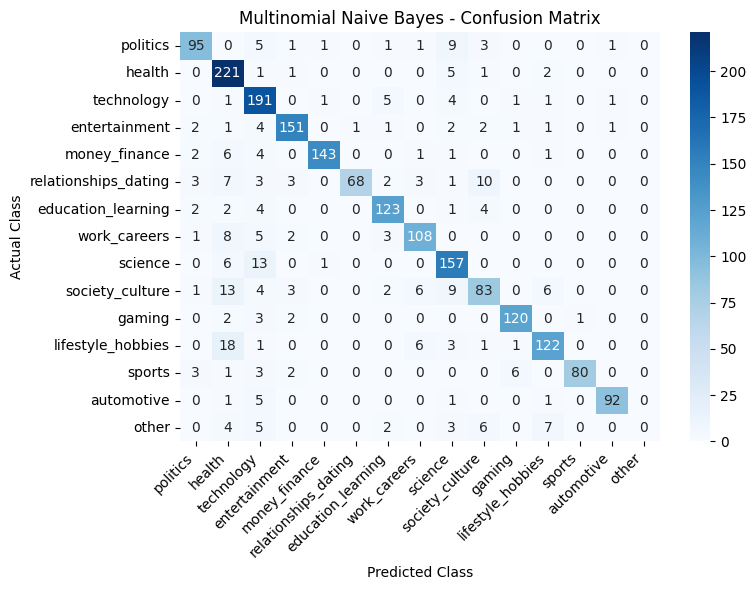


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9204,0.8889,0.9043,117.0000
health,0.9095,0.9134,0.9114,231.0000
technology,0.8667,0.8878,0.8771,205.0000
entertainment,0.8970,0.8862,0.8916,167.0000
money_finance,0.9673,0.9367,0.9518,158.0000
relationships_dating,0.8900,0.8900,0.8900,100.0000
education_learning,0.9085,0.9485,0.9281,136.0000
work_careers,0.8538,0.8740,0.8638,127.0000
science,0.8432,0.8814,0.8619,177.0000
society_culture,0.8120,0.7480,0.7787,127.0000




--- Confusion Matrix ---


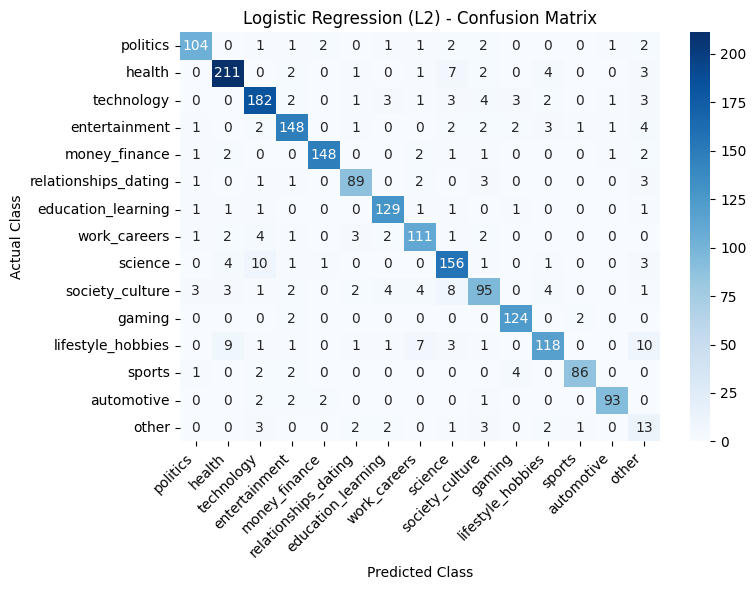


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9252,0.8462,0.8839,117.000
health,0.8884,0.8615,0.8747,231.000
technology,0.8373,0.8537,0.8454,205.000
entertainment,0.9226,0.8563,0.8882,167.000
money_finance,0.9474,0.9114,0.9290,158.000
relationships_dating,0.8614,0.8700,0.8657,100.000
education_learning,0.9071,0.9338,0.9203,136.000
work_careers,0.8529,0.9134,0.8821,127.000
science,0.8372,0.8136,0.8252,177.000
society_culture,0.9481,0.5748,0.7157,127.000




--- Confusion Matrix ---


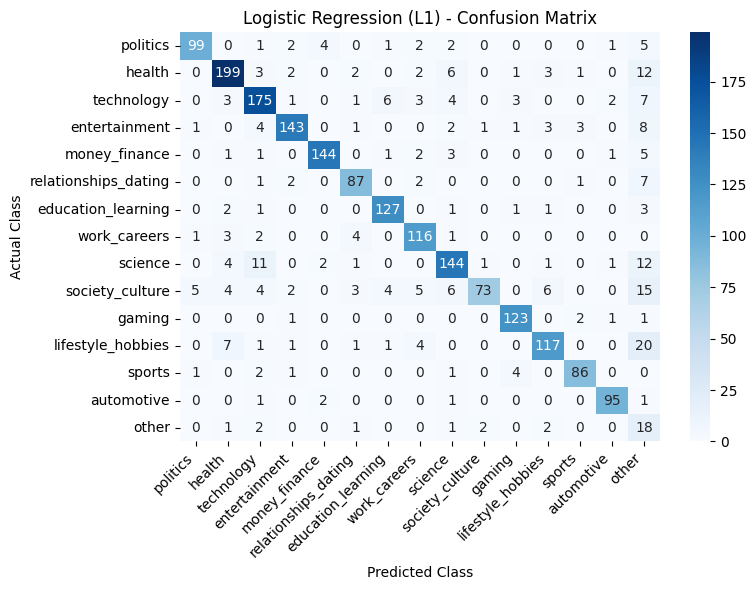


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9027,0.8718,0.8870,117.0000
health,0.8921,0.9307,0.9110,231.0000
technology,0.8638,0.8976,0.8804,205.0000
entertainment,0.9096,0.9042,0.9069,167.0000
money_finance,0.9675,0.9430,0.9551,158.0000
relationships_dating,0.9278,0.9000,0.9137,100.0000
education_learning,0.9220,0.9559,0.9386,136.0000
work_careers,0.8712,0.9055,0.8880,127.0000
science,0.8525,0.8814,0.8667,177.0000
society_culture,0.8378,0.7323,0.7815,127.0000




--- Confusion Matrix ---


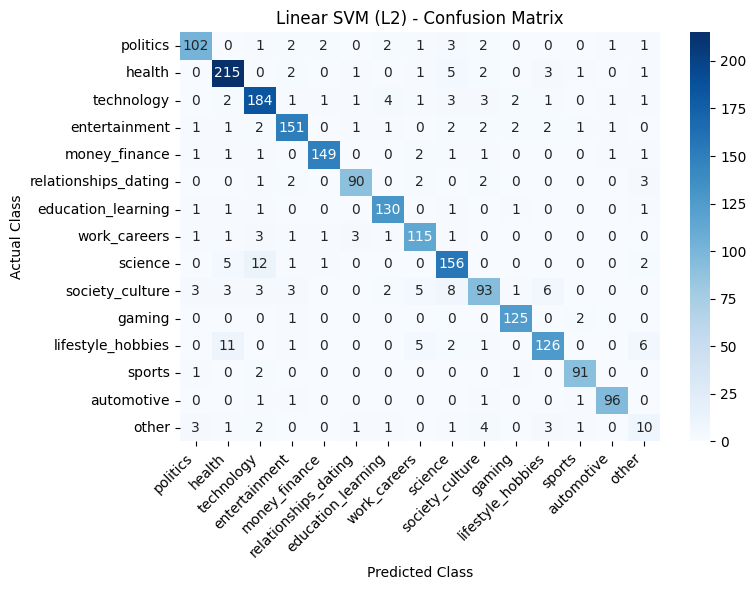


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9358,0.8718,0.9027,117.0000
health,0.8785,0.9394,0.9079,231.0000
technology,0.8775,0.8732,0.8753,205.0000
entertainment,0.9048,0.9102,0.9075,167.0000
money_finance,0.9803,0.9430,0.9613,158.0000
relationships_dating,0.9375,0.9000,0.9184,100.0000
education_learning,0.9034,0.9632,0.9324,136.0000
work_careers,0.8417,0.9213,0.8797,127.0000
science,0.8807,0.8757,0.8782,177.0000
society_culture,0.8378,0.7323,0.7815,127.0000




--- Confusion Matrix ---


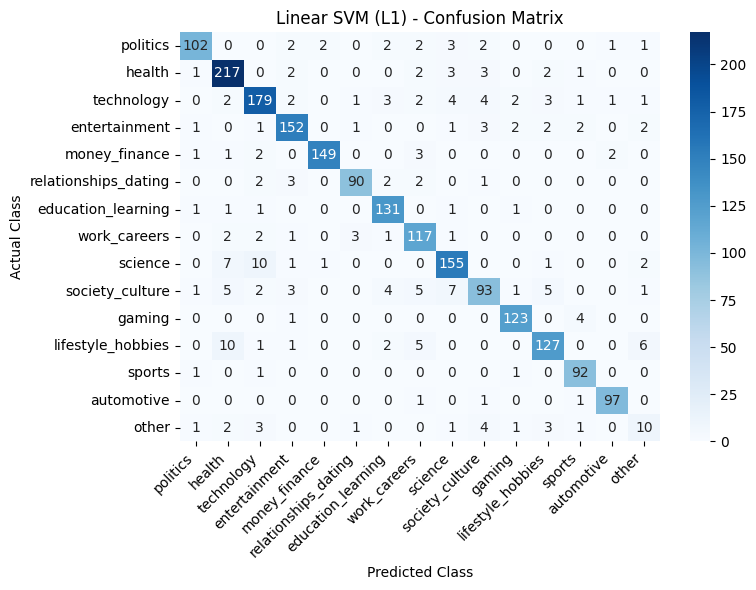


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8430,0.8718,0.8571,117.000
health,0.8578,0.8615,0.8596,231.000
technology,0.8549,0.8049,0.8291,205.000
entertainment,0.9103,0.8503,0.8793,167.000
money_finance,0.9193,0.9367,0.9279,158.000
relationships_dating,0.8750,0.8400,0.8571,100.000
education_learning,0.8600,0.9485,0.9021,136.000
work_careers,0.8058,0.8819,0.8421,127.000
science,0.7835,0.8588,0.8194,177.000
society_culture,0.8000,0.6299,0.7048,127.000




--- Confusion Matrix ---


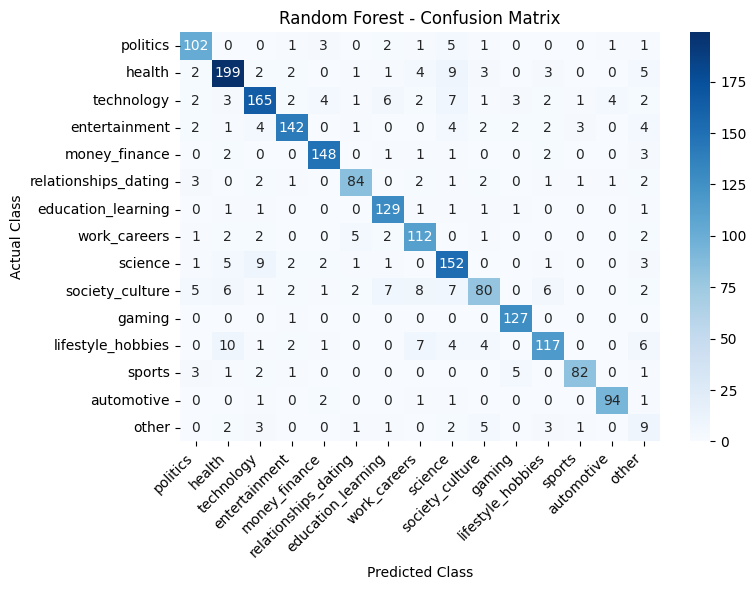


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9245,0.8376,0.8789,117.0000
health,0.8346,0.9177,0.8742,231.0000
technology,0.7854,0.8390,0.8113,205.0000
entertainment,0.9290,0.8623,0.8944,167.0000
money_finance,0.9198,0.9430,0.9312,158.0000
relationships_dating,0.9062,0.8700,0.8878,100.0000
education_learning,0.8776,0.9485,0.9117,136.0000
work_careers,0.8286,0.9134,0.8689,127.0000
science,0.8663,0.8418,0.8539,177.0000
society_culture,0.7719,0.6929,0.7303,127.0000




--- Confusion Matrix ---


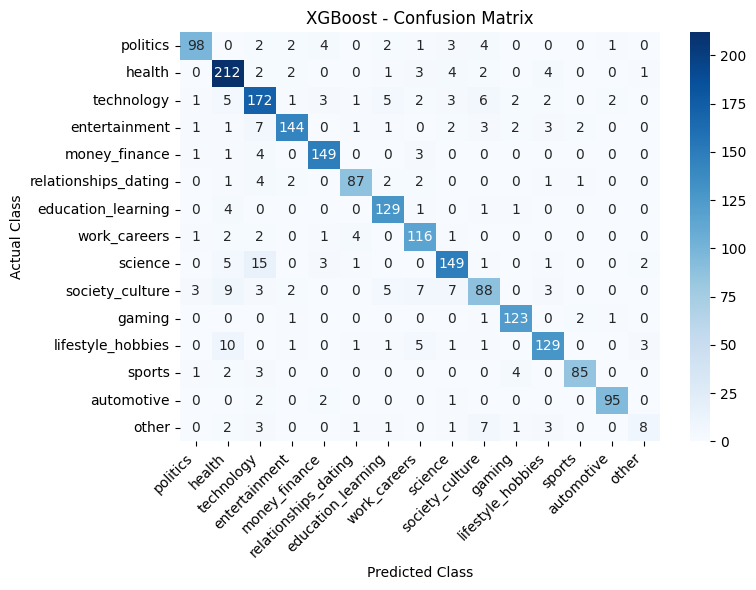

In [39]:
display_model_evaluations(confusion_matrices_bow, class_reports_bow, topics)

### TF-IDF

In [40]:
metrics_df_tfidf, confusion_matrices_tfidf, class_reports_tfidf = evaluate_models(
    X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf, target_names=topics
)

c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [41]:
display(metrics_df_tfidf.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L1),0.901319,0.900417,0.901319,0.900239,0.876045,0.990092
Linear SVM (L2),0.898388,0.896777,0.898388,0.896953,0.868711,0.990464
Logistic Regression (L2),0.892526,0.896409,0.892526,0.893890,0.868671,0.993232
XGBoost,0.873473,0.872906,0.873473,0.871884,0.849758,0.988973
Logistic Regression (L1),0.860772,0.877838,0.860772,0.867449,0.838962,0.987760
Random Forest,0.856375,0.866783,0.856375,0.859135,0.834280,0.986954
Multinomial Naive Bayes,0.861749,0.857376,0.861749,0.856171,0.811624,0.989977



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8839,0.8462,0.8646,117.0000
health,0.7603,0.9610,0.8489,231.0000
technology,0.7782,0.9073,0.8378,205.0000
entertainment,0.9264,0.9042,0.9152,167.0000
money_finance,0.9667,0.9177,0.9416,158.0000
relationships_dating,0.9726,0.7100,0.8208,100.0000
education_learning,0.8929,0.9191,0.9058,136.0000
work_careers,0.8699,0.8425,0.8560,127.0000
science,0.8211,0.8814,0.8501,177.0000
society_culture,0.7328,0.6693,0.6996,127.0000




--- Confusion Matrix ---


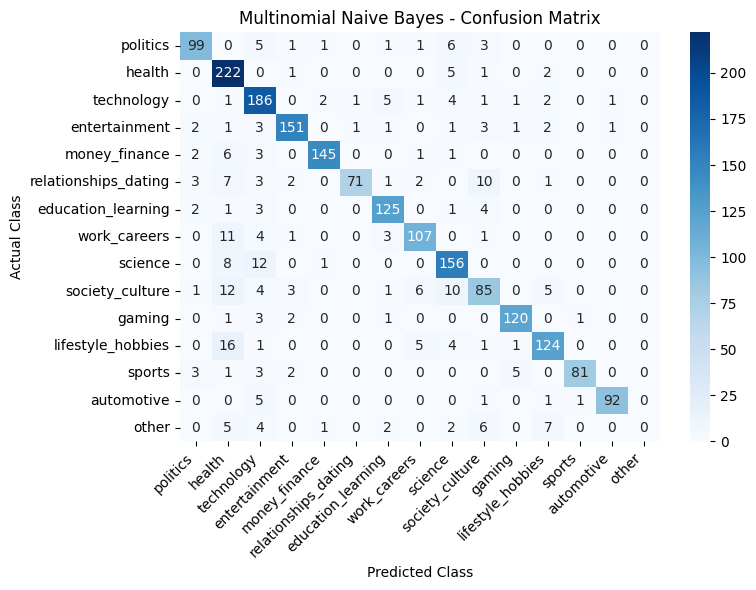


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9204,0.8889,0.9043,117.0000
health,0.9142,0.9221,0.9181,231.0000
technology,0.8641,0.8683,0.8662,205.0000
entertainment,0.9085,0.8922,0.9003,167.0000
money_finance,0.9671,0.9304,0.9484,158.0000
relationships_dating,0.9109,0.9200,0.9154,100.0000
education_learning,0.9155,0.9559,0.9353,136.0000
work_careers,0.8626,0.8898,0.8760,127.0000
science,0.8634,0.8927,0.8778,177.0000
society_culture,0.8291,0.7638,0.7951,127.0000




--- Confusion Matrix ---


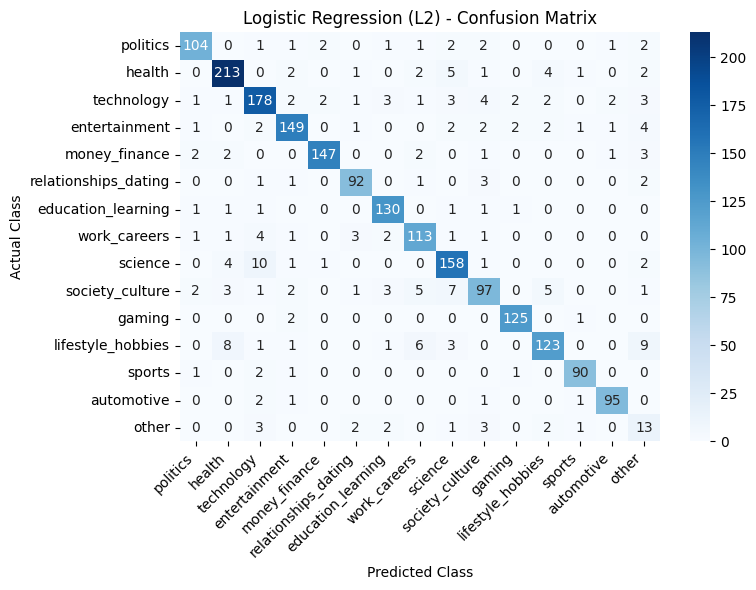


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9074,0.8376,0.8711,117.0000
health,0.8855,0.8701,0.8777,231.0000
technology,0.8528,0.8195,0.8358,205.0000
entertainment,0.9351,0.8623,0.8972,167.0000
money_finance,0.9484,0.9304,0.9393,158.0000
relationships_dating,0.8700,0.8700,0.8700,100.0000
education_learning,0.8936,0.9265,0.9097,136.0000
work_careers,0.8271,0.8661,0.8462,127.0000
science,0.8287,0.8475,0.8380,177.0000
society_culture,0.7833,0.7402,0.7611,127.0000




--- Confusion Matrix ---


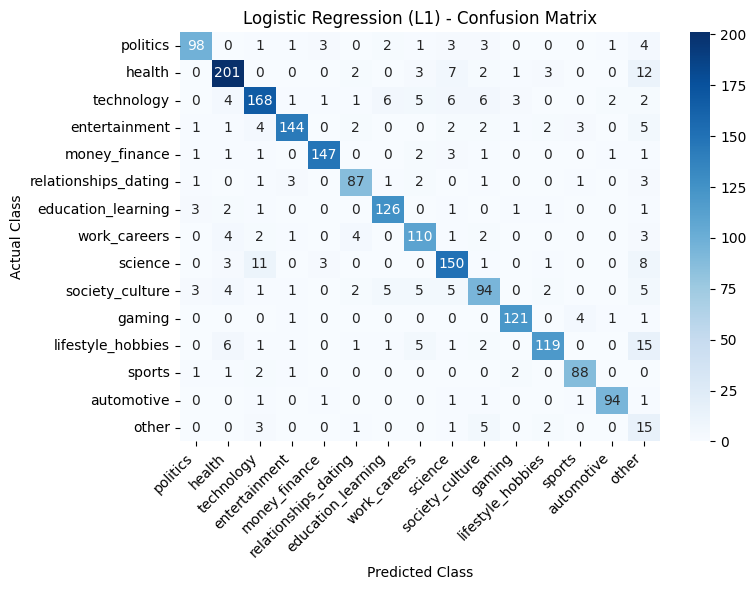


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8966,0.8889,0.8927,117.0000
health,0.8921,0.9307,0.9110,231.0000
technology,0.8744,0.8829,0.8786,205.0000
entertainment,0.9268,0.9102,0.9184,167.0000
money_finance,0.9618,0.9557,0.9587,158.0000
relationships_dating,0.9388,0.9200,0.9293,100.0000
education_learning,0.9161,0.9632,0.9391,136.0000
work_careers,0.8667,0.9213,0.8931,127.0000
science,0.8525,0.8814,0.8667,177.0000
society_culture,0.8364,0.7244,0.7764,127.0000




--- Confusion Matrix ---


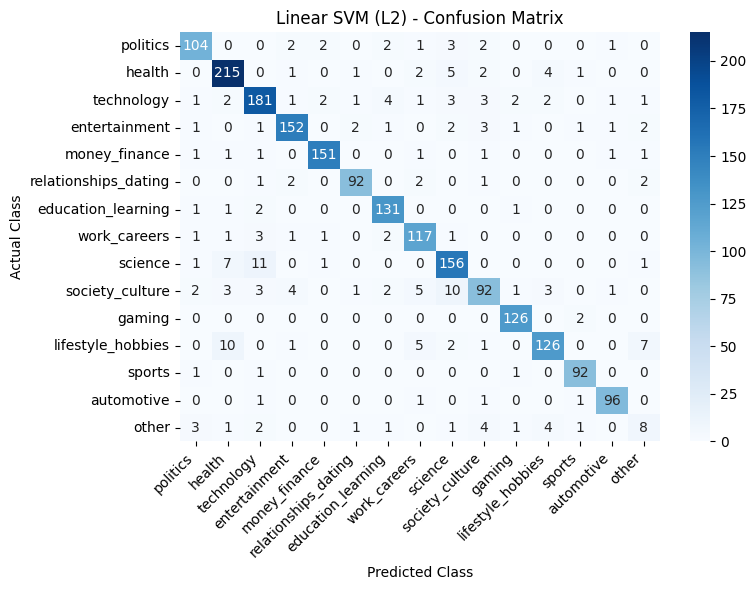


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9444,0.8718,0.9067,117.0000
health,0.8875,0.9221,0.9045,231.0000
technology,0.8835,0.8878,0.8856,205.0000
entertainment,0.9157,0.9102,0.9129,167.0000
money_finance,0.9740,0.9494,0.9615,158.0000
relationships_dating,0.9091,0.9000,0.9045,100.0000
education_learning,0.9184,0.9926,0.9541,136.0000
work_careers,0.8551,0.9291,0.8906,127.0000
science,0.8626,0.8870,0.8747,177.0000
society_culture,0.8333,0.7480,0.7884,127.0000




--- Confusion Matrix ---


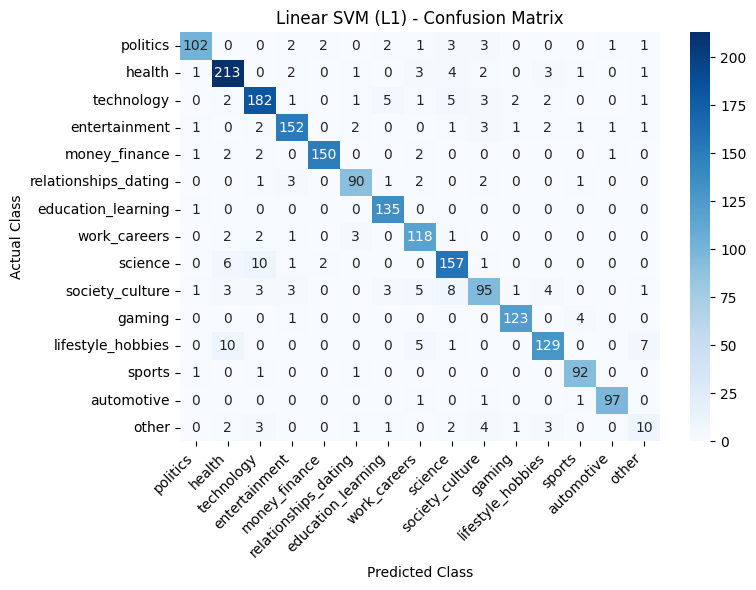


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8772,0.8547,0.8658,117.0000
health,0.8471,0.8874,0.8668,231.0000
technology,0.8556,0.7805,0.8163,205.0000
entertainment,0.9161,0.8503,0.8820,167.0000
money_finance,0.9299,0.9241,0.9270,158.0000
relationships_dating,0.8854,0.8500,0.8673,100.0000
education_learning,0.8792,0.9632,0.9193,136.0000
work_careers,0.8042,0.9055,0.8519,127.0000
science,0.7789,0.8362,0.8065,177.0000
society_culture,0.8776,0.6772,0.7644,127.0000




--- Confusion Matrix ---


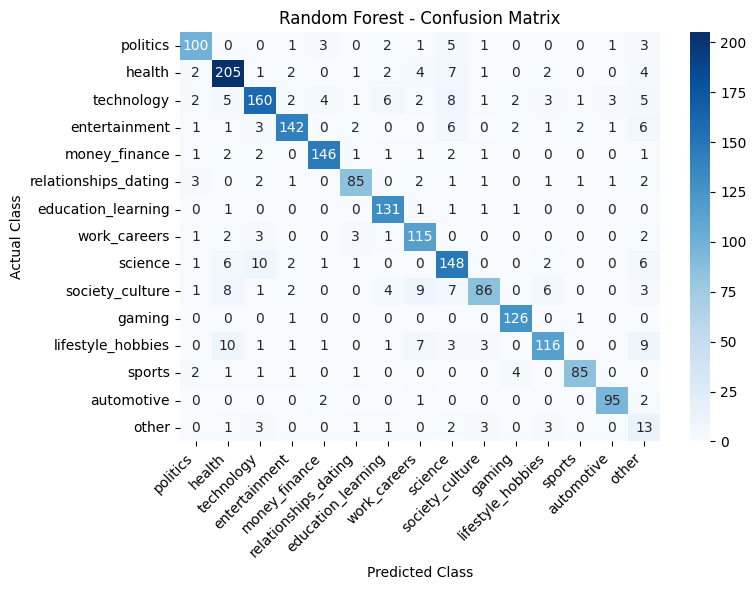


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9340,0.8462,0.8879,117.0000
health,0.8543,0.9134,0.8828,231.0000
technology,0.7733,0.8488,0.8093,205.0000
entertainment,0.9172,0.8623,0.8889,167.0000
money_finance,0.9308,0.9367,0.9338,158.0000
relationships_dating,0.9255,0.8700,0.8969,100.0000
education_learning,0.9034,0.9632,0.9324,136.0000
work_careers,0.8406,0.9134,0.8755,127.0000
science,0.8475,0.8475,0.8475,177.0000
society_culture,0.7607,0.7008,0.7295,127.0000




--- Confusion Matrix ---


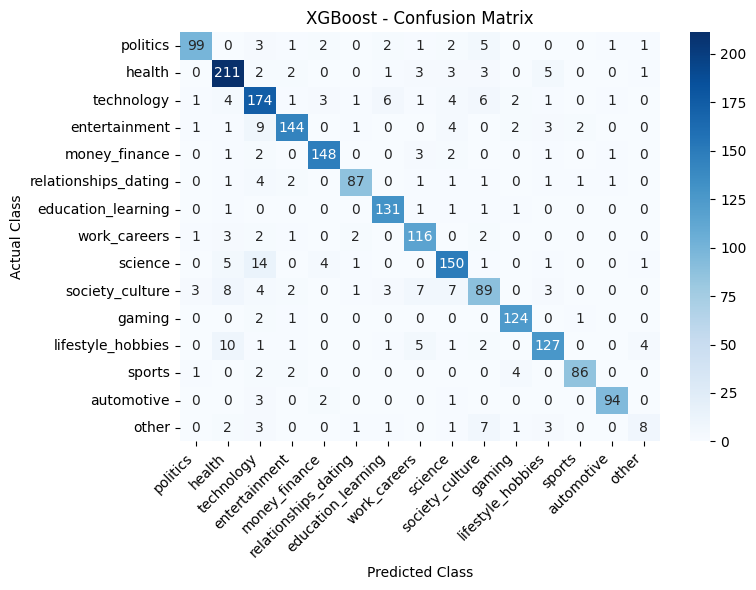

In [42]:
display_model_evaluations(confusion_matrices_tfidf, class_reports_tfidf, topics)

### 1-hot vectors

In [43]:
metrics_df_onehot, confusion_matrices_onehot, class_reports_onehot = evaluate_models(
    X_train_onehot, X_test_onehot, y_train_onehot, y_test_onehot, target_names=topics
)

c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [44]:
display(metrics_df_bow.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L1),0.895945,0.895325,0.895945,0.894854,0.870321,0.989701
Linear SVM (L2),0.895457,0.895074,0.895457,0.894756,0.869054,0.990310
Logistic Regression (L2),0.882755,0.888218,0.882755,0.884648,0.857695,0.992271
XGBoost,0.871519,0.870934,0.871519,0.869640,0.847657,0.989332
Logistic Regression (L1),0.852956,0.885961,0.852956,0.863898,0.833957,0.986722
Random Forest,0.851001,0.856019,0.851001,0.851808,0.822685,0.986716
Multinomial Naive Bayes,0.856864,0.854164,0.856864,0.851015,0.806238,0.989742



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8716,0.8120,0.8407,117.0000
health,0.7568,0.9567,0.8451,231.0000
technology,0.7640,0.9317,0.8396,205.0000
entertainment,0.9091,0.8982,0.9036,167.0000
money_finance,0.9793,0.8987,0.9373,158.0000
relationships_dating,0.9853,0.6700,0.7976,100.0000
education_learning,0.8849,0.9044,0.8945,136.0000
work_careers,0.8629,0.8425,0.8526,127.0000
science,0.7970,0.8870,0.8396,177.0000
society_culture,0.7345,0.6535,0.6917,127.0000




--- Confusion Matrix ---


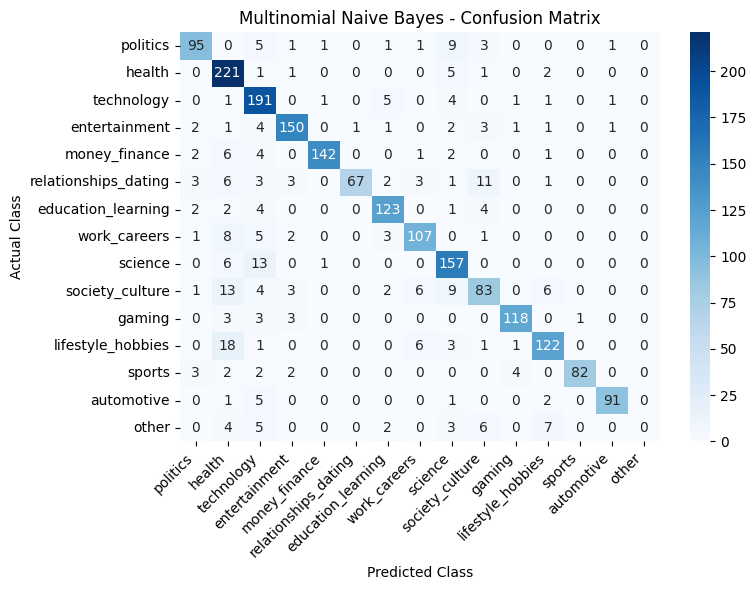


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9286,0.8889,0.9083,117.0000
health,0.9138,0.9177,0.9158,231.0000
technology,0.8578,0.8829,0.8702,205.0000
entertainment,0.9018,0.8802,0.8909,167.0000
money_finance,0.9671,0.9304,0.9484,158.0000
relationships_dating,0.8725,0.8900,0.8812,100.0000
education_learning,0.9091,0.9559,0.9319,136.0000
work_careers,0.8473,0.8740,0.8605,127.0000
science,0.8432,0.8814,0.8619,177.0000
society_culture,0.7966,0.7402,0.7673,127.0000




--- Confusion Matrix ---


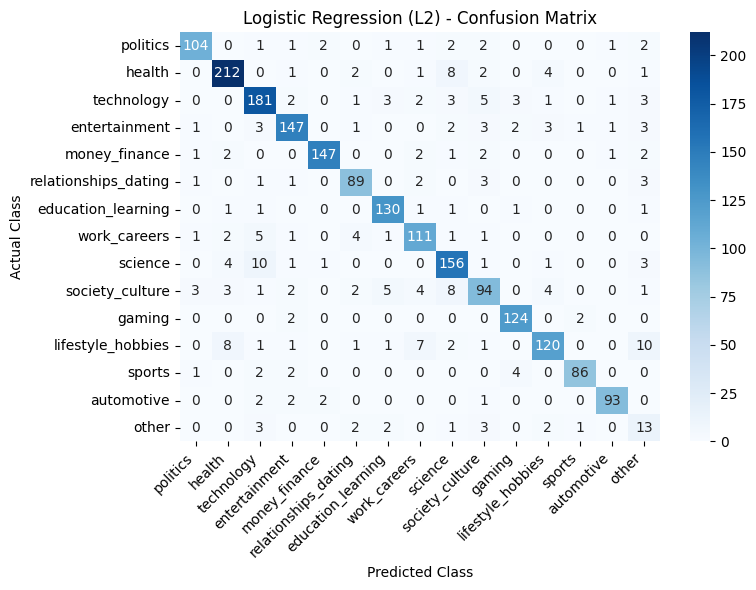


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9182,0.8632,0.8899,117.0000
health,0.8904,0.8788,0.8845,231.0000
technology,0.8593,0.8341,0.8465,205.0000
entertainment,0.9276,0.8443,0.8840,167.0000
money_finance,0.9527,0.8924,0.9216,158.0000
relationships_dating,0.8673,0.8500,0.8586,100.0000
education_learning,0.9021,0.9485,0.9247,136.0000
work_careers,0.8507,0.8976,0.8736,127.0000
science,0.8659,0.8023,0.8328,177.0000
society_culture,0.8241,0.7008,0.7574,127.0000




--- Confusion Matrix ---


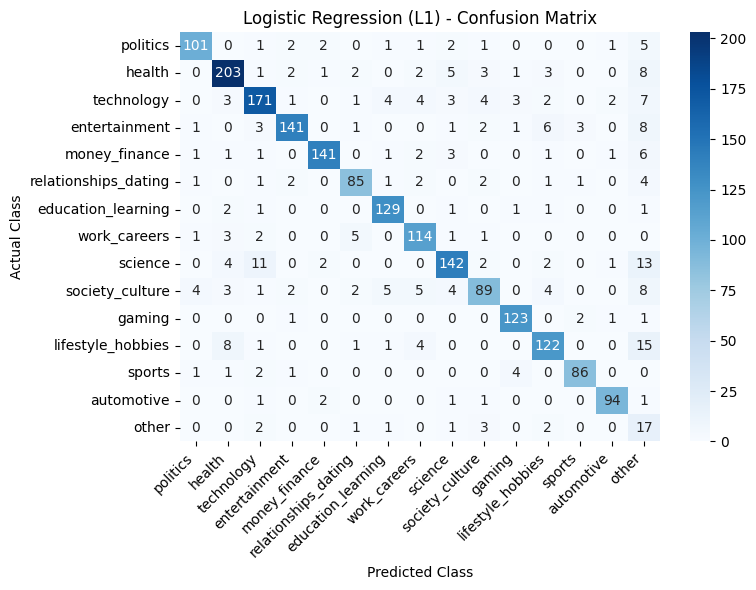


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9196,0.8803,0.8996,117.0000
health,0.8963,0.9351,0.9153,231.0000
technology,0.8598,0.8976,0.8783,205.0000
entertainment,0.9091,0.8982,0.9036,167.0000
money_finance,0.9675,0.9430,0.9551,158.0000
relationships_dating,0.9091,0.9000,0.9045,100.0000
education_learning,0.9291,0.9632,0.9458,136.0000
work_careers,0.8864,0.9213,0.9035,127.0000
science,0.8619,0.8814,0.8715,177.0000
society_culture,0.8333,0.7480,0.7884,127.0000




--- Confusion Matrix ---


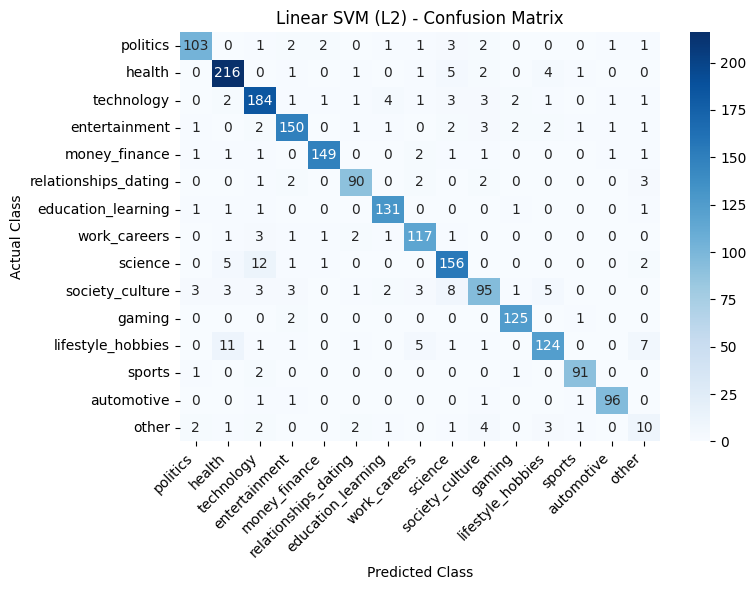


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9439,0.8632,0.9018,117.0000
health,0.8740,0.9307,0.9015,231.0000
technology,0.8719,0.8634,0.8676,205.0000
entertainment,0.9042,0.9042,0.9042,167.0000
money_finance,0.9804,0.9494,0.9646,158.0000
relationships_dating,0.9091,0.9000,0.9045,100.0000
education_learning,0.9103,0.9706,0.9395,136.0000
work_careers,0.8406,0.9134,0.8755,127.0000
science,0.8857,0.8757,0.8807,177.0000
society_culture,0.8174,0.7402,0.7769,127.0000




--- Confusion Matrix ---


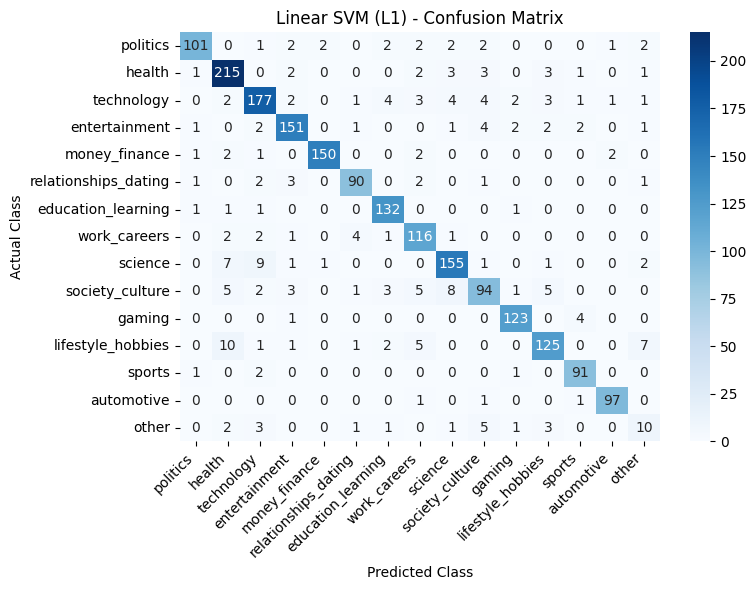


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8621,0.8547,0.8584,117.000
health,0.8603,0.8528,0.8565,231.000
technology,0.8438,0.7902,0.8161,205.000
entertainment,0.9161,0.8503,0.8820,167.000
money_finance,0.9114,0.9114,0.9114,158.000
relationships_dating,0.8515,0.8600,0.8557,100.000
education_learning,0.8667,0.9559,0.9091,136.000
work_careers,0.8014,0.8898,0.8433,127.000
science,0.7677,0.8588,0.8107,177.000
society_culture,0.8235,0.6614,0.7336,127.000




--- Confusion Matrix ---


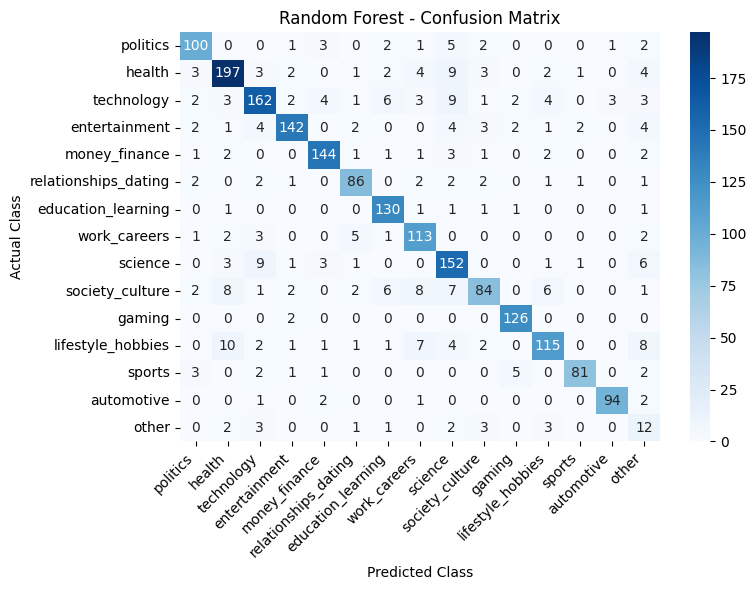


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9340,0.8462,0.8879,117.000
health,0.8577,0.9134,0.8847,231.000
technology,0.7953,0.8341,0.8143,205.000
entertainment,0.9231,0.8623,0.8916,167.000
money_finance,0.9259,0.9494,0.9375,158.000
relationships_dating,0.8980,0.8800,0.8889,100.000
education_learning,0.8707,0.9412,0.9046,136.000
work_careers,0.8273,0.9055,0.8647,127.000
science,0.8380,0.8475,0.8427,177.000
society_culture,0.7731,0.7244,0.7480,127.000




--- Confusion Matrix ---


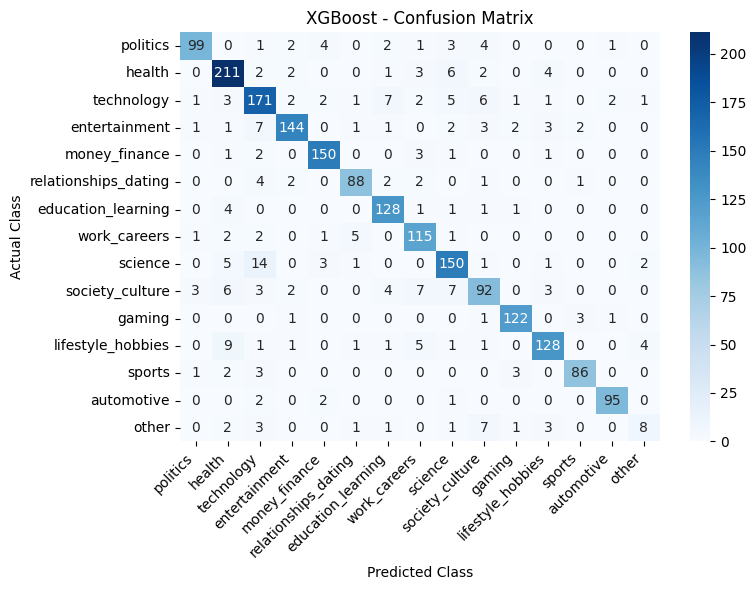

In [45]:
display_model_evaluations(confusion_matrices_onehot, class_reports_onehot, topics)

### N-Grams

In [46]:
metrics_df_grams, confusion_matrices_grams, class_reports_grams= evaluate_models(
    X_train_grams, X_test_grams, y_train_grams, y_test_grams, target_names=topics
)

c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [47]:
display(metrics_df_grams.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L2),0.902296,0.901503,0.902296,0.901153,0.881901,0.992071
Linear SVM (L1),0.893014,0.892426,0.893014,0.892034,0.869031,0.989859
Logistic Regression (L2),0.885198,0.888334,0.885198,0.886225,0.862050,0.992324
XGBoost,0.874450,0.873329,0.874450,0.872700,0.850056,0.989345
Logistic Regression (L1),0.860283,0.866264,0.860283,0.862377,0.840165,0.987198
Random Forest,0.860772,0.859016,0.860772,0.858857,0.830673,0.985151
Multinomial Naive Bayes,0.844162,0.848982,0.844162,0.839157,0.796364,0.987073



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8909,0.8376,0.8634,117.0000
health,0.6904,0.9654,0.8051,231.0000
technology,0.7245,0.9366,0.8170,205.0000
entertainment,0.8889,0.9102,0.8994,167.0000
money_finance,0.9722,0.8861,0.9272,158.0000
relationships_dating,0.9697,0.6400,0.7711,100.0000
education_learning,0.9225,0.8750,0.8981,136.0000
work_careers,0.8629,0.8425,0.8526,127.0000
science,0.8105,0.8701,0.8392,177.0000
society_culture,0.7745,0.6220,0.6900,127.0000




--- Confusion Matrix ---


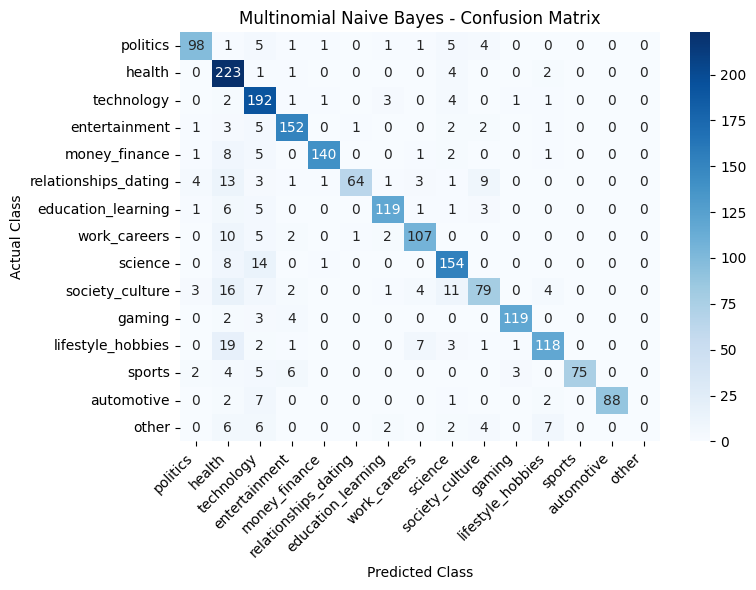


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8908,0.9060,0.8983,117.0000
health,0.9119,0.8961,0.9039,231.0000
technology,0.8632,0.8927,0.8777,205.0000
entertainment,0.9012,0.8743,0.8875,167.0000
money_finance,0.9671,0.9304,0.9484,158.0000
relationships_dating,0.8980,0.8800,0.8889,100.0000
education_learning,0.9137,0.9338,0.9236,136.0000
work_careers,0.8550,0.8819,0.8682,127.0000
science,0.8368,0.8983,0.8665,177.0000
society_culture,0.7983,0.7480,0.7724,127.0000




--- Confusion Matrix ---


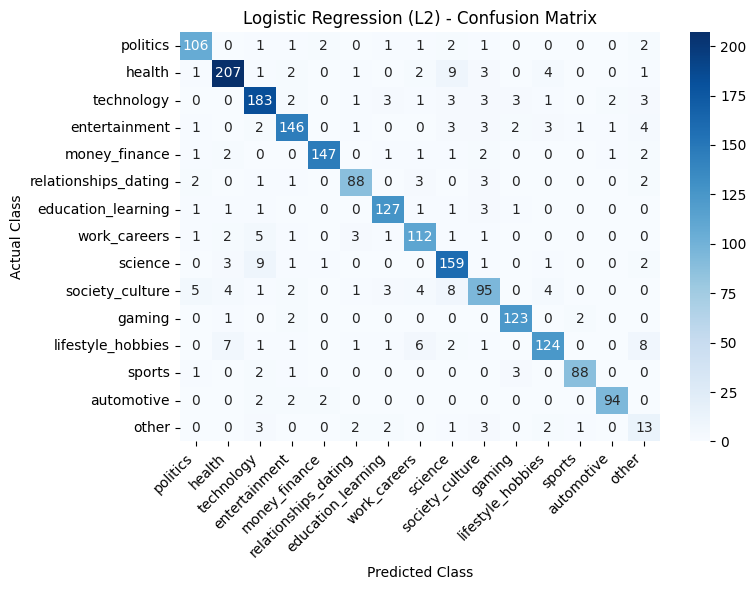


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9074,0.8376,0.8711,117.0000
health,0.8382,0.8745,0.8559,231.0000
technology,0.8382,0.8341,0.8362,205.0000
entertainment,0.9103,0.8503,0.8793,167.0000
money_finance,0.9172,0.9114,0.9143,158.0000
relationships_dating,0.8889,0.8800,0.8844,100.0000
education_learning,0.9071,0.9338,0.9203,136.0000
work_careers,0.8409,0.8740,0.8571,127.0000
science,0.8268,0.8362,0.8315,177.0000
society_culture,0.7686,0.7323,0.7500,127.0000




--- Confusion Matrix ---


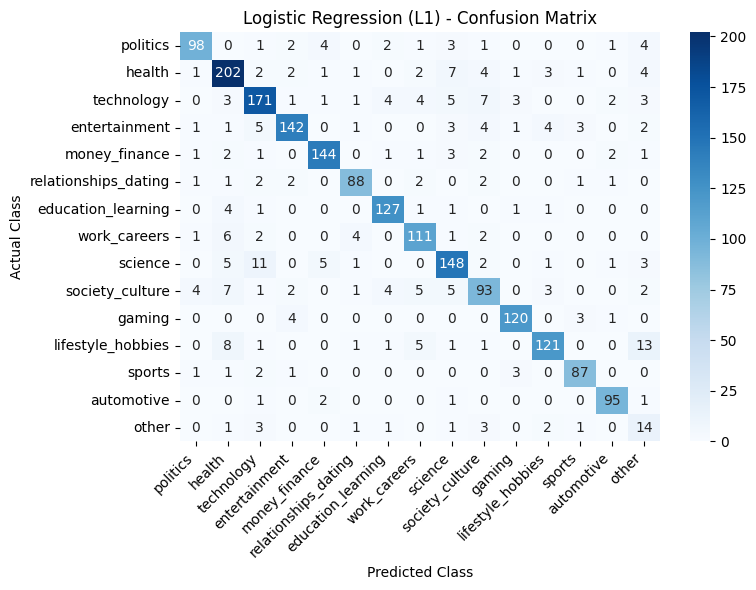


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8957,0.8803,0.8879,117.0000
health,0.9000,0.9351,0.9172,231.0000
technology,0.8486,0.9024,0.8747,205.0000
entertainment,0.9162,0.9162,0.9162,167.0000
money_finance,0.9803,0.9430,0.9613,158.0000
relationships_dating,0.9208,0.9300,0.9254,100.0000
education_learning,0.9348,0.9485,0.9416,136.0000
work_careers,0.8657,0.9134,0.8889,127.0000
science,0.8736,0.8983,0.8858,177.0000
society_culture,0.8532,0.7323,0.7881,127.0000




--- Confusion Matrix ---


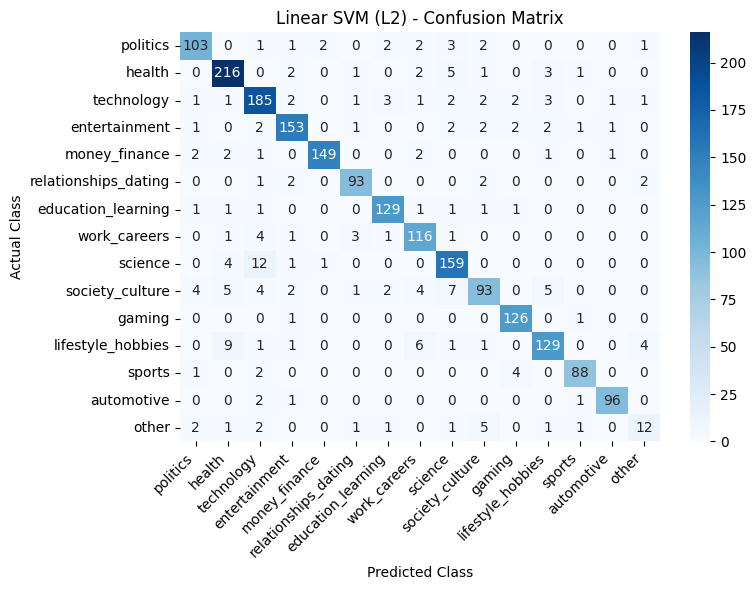


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9027,0.8718,0.8870,117.000
health,0.8954,0.9264,0.9106,231.000
technology,0.8812,0.8683,0.8747,205.000
entertainment,0.8994,0.9102,0.9048,167.000
money_finance,0.9801,0.9367,0.9579,158.000
relationships_dating,0.9200,0.9200,0.9200,100.000
education_learning,0.9091,0.9559,0.9319,136.000
work_careers,0.8417,0.9213,0.8797,127.000
science,0.8486,0.8870,0.8674,177.000
society_culture,0.8426,0.7165,0.7745,127.000




--- Confusion Matrix ---


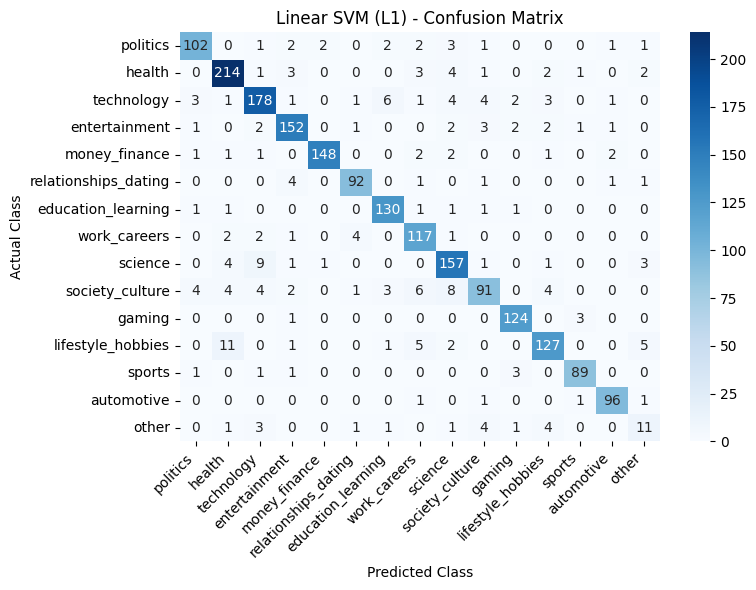


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8279,0.8632,0.8452,117.0000
health,0.8511,0.8658,0.8584,231.0000
technology,0.8586,0.8293,0.8437,205.0000
entertainment,0.8931,0.8503,0.8712,167.0000
money_finance,0.9308,0.9367,0.9338,158.0000
relationships_dating,0.8969,0.8700,0.8832,100.0000
education_learning,0.8562,0.9632,0.9066,136.0000
work_careers,0.8209,0.8661,0.8429,127.0000
science,0.7868,0.8757,0.8289,177.0000
society_culture,0.7652,0.6929,0.7273,127.0000




--- Confusion Matrix ---


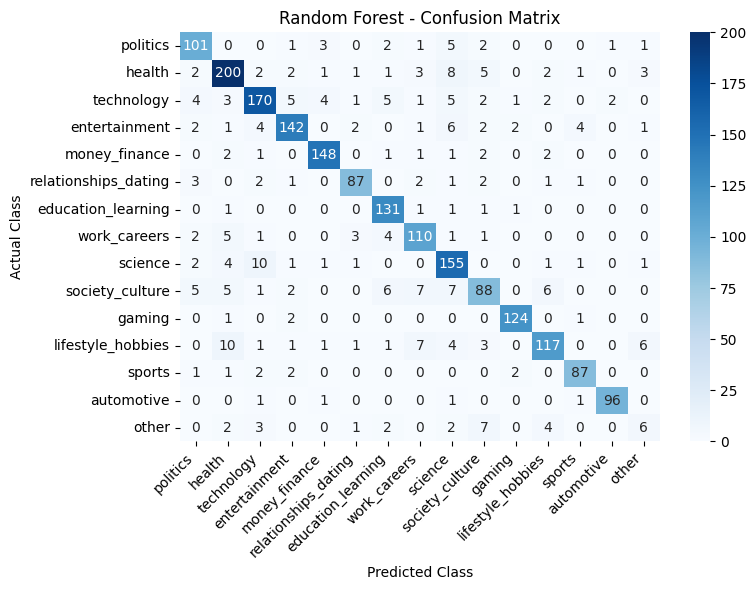


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9159,0.8376,0.8750,117.0000
health,0.8508,0.9134,0.8810,231.0000
technology,0.7926,0.8390,0.8152,205.0000
entertainment,0.9295,0.8683,0.8978,167.0000
money_finance,0.9198,0.9430,0.9312,158.0000
relationships_dating,0.8990,0.8900,0.8945,100.0000
education_learning,0.8836,0.9485,0.9149,136.0000
work_careers,0.8333,0.9055,0.8679,127.0000
science,0.8475,0.8475,0.8475,177.0000
society_culture,0.7826,0.7087,0.7438,127.0000




--- Confusion Matrix ---


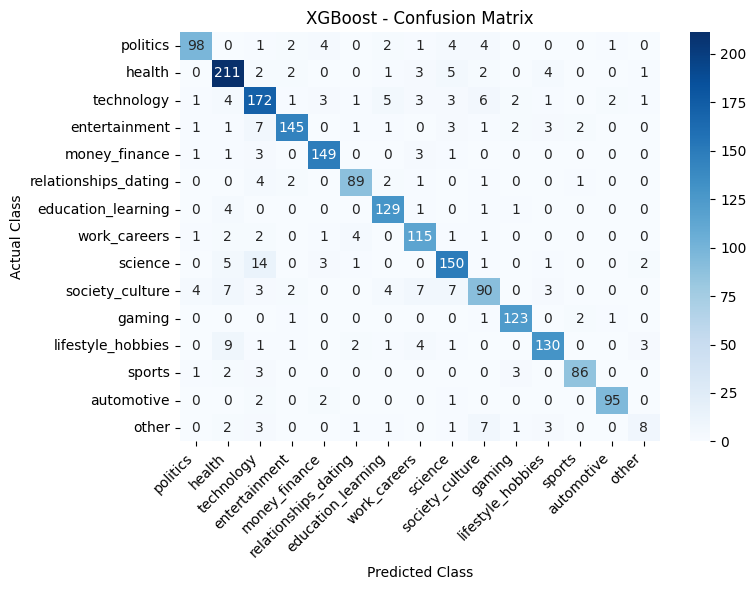

In [48]:
display_model_evaluations(confusion_matrices_grams, class_reports_grams, topics)

### Embeddings Mean

In [49]:
metrics_df_embeddings_mean, confusion_matrices_embeddings_mean, class_reports_embeddings_mean = evaluate_models(
    X_train_embeddings_mean, X_test_embeddings_mean, y_train_embeddings_mean, y_test_embeddings_mean, target_names=topics,is_embeddings=True
)

c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [50]:
display(metrics_df_embeddings_mean.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L1),0.891549,0.892052,0.891549,0.891245,0.865384,0.991184
Linear SVM (L2),0.889595,0.891234,0.889595,0.889421,0.863811,0.991763
Logistic Regression (L2),0.883732,0.893090,0.883732,0.887053,0.859765,0.993282
Logistic Regression (L1),0.879336,0.883939,0.879336,0.880725,0.854886,0.992455
XGBoost,0.868588,0.870031,0.868588,0.866659,0.841159,0.989425
Random Forest,0.860772,0.865649,0.860772,0.857402,0.827752,0.986072
Gaussian Naive Bayes,0.834392,0.849538,0.834392,0.839243,0.813349,0.986750



MODEL: Gaussian Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8611,0.7949,0.8267,117.0000
health,0.8766,0.8918,0.8841,231.0000
technology,0.7768,0.8488,0.8112,205.0000
entertainment,0.9018,0.8802,0.8909,167.0000
money_finance,0.8800,0.8354,0.8571,158.0000
relationships_dating,0.9294,0.7900,0.8541,100.0000
education_learning,0.8955,0.8824,0.8889,136.0000
work_careers,0.8293,0.8031,0.8160,127.0000
science,0.8172,0.8588,0.8375,177.0000
society_culture,0.6901,0.7717,0.7286,127.0000




--- Confusion Matrix ---


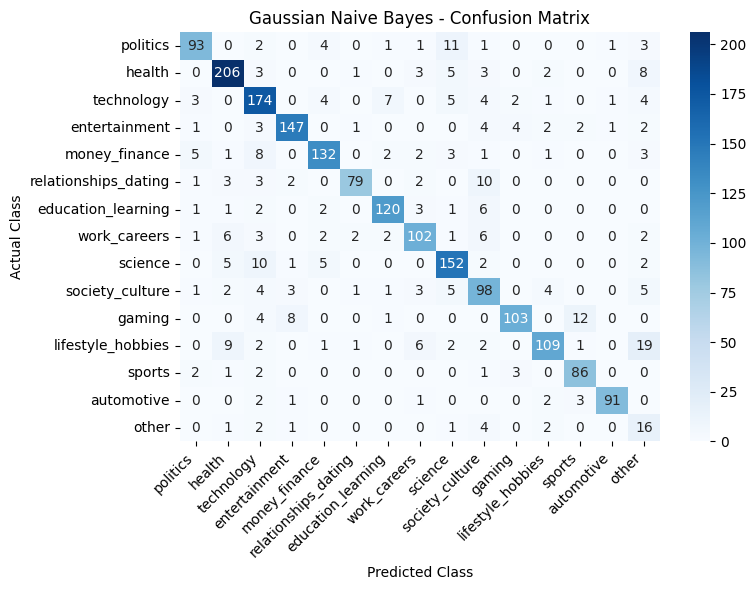


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8803,0.8803,0.8803,117.0000
health,0.9079,0.9394,0.9234,231.0000
technology,0.8421,0.8585,0.8502,205.0000
entertainment,0.9500,0.9102,0.9297,167.0000
money_finance,0.9404,0.8987,0.9191,158.0000
relationships_dating,0.9263,0.8800,0.9026,100.0000
education_learning,0.9085,0.9485,0.9281,136.0000
work_careers,0.8712,0.9055,0.8880,127.0000
science,0.8864,0.8814,0.8839,177.0000
society_culture,0.8393,0.7402,0.7866,127.0000




--- Confusion Matrix ---


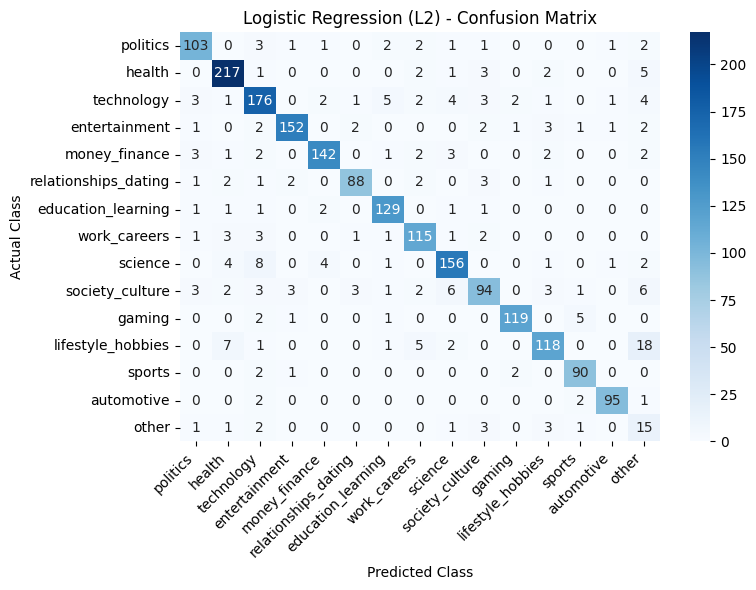


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8760,0.9060,0.8908,117.0000
health,0.8945,0.9177,0.9060,231.0000
technology,0.8366,0.8244,0.8305,205.0000
entertainment,0.9379,0.9042,0.9207,167.0000
money_finance,0.9396,0.8861,0.9121,158.0000
relationships_dating,0.9062,0.8700,0.8878,100.0000
education_learning,0.8836,0.9485,0.9149,136.0000
work_careers,0.8561,0.8898,0.8726,127.0000
science,0.8511,0.9040,0.8767,177.0000
society_culture,0.8250,0.7795,0.8016,127.0000




--- Confusion Matrix ---


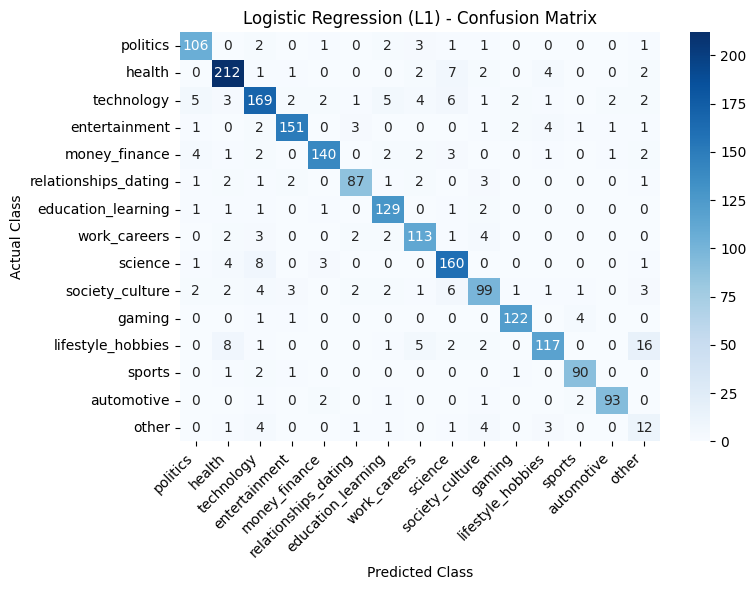


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9182,0.8632,0.8899,117.0000
health,0.8884,0.9307,0.9091,231.0000
technology,0.8592,0.8634,0.8613,205.0000
entertainment,0.9379,0.9042,0.9207,167.0000
money_finance,0.9250,0.9367,0.9308,158.0000
relationships_dating,0.9255,0.8700,0.8969,100.0000
education_learning,0.8980,0.9706,0.9329,136.0000
work_careers,0.8561,0.9370,0.8947,127.0000
science,0.8659,0.8757,0.8708,177.0000
society_culture,0.8750,0.7165,0.7879,127.0000




--- Confusion Matrix ---


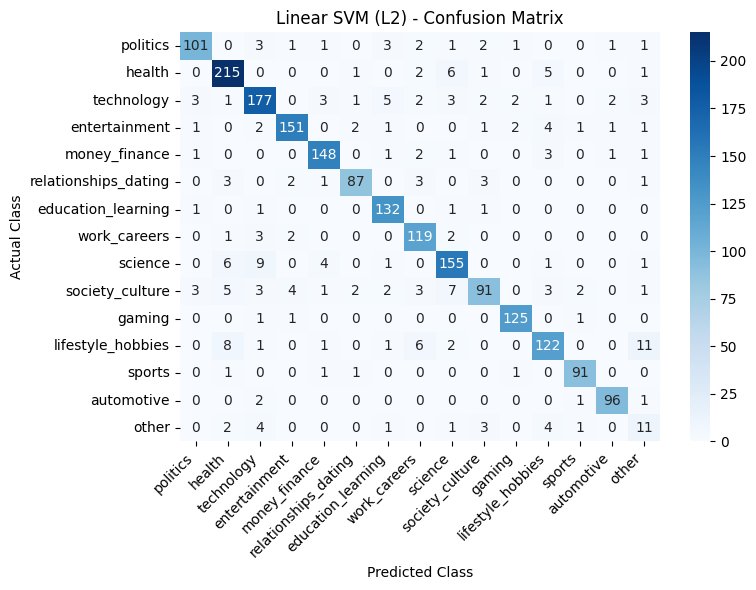


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9043,0.8889,0.8966,117.0000
health,0.8776,0.9307,0.9034,231.0000
technology,0.8650,0.8439,0.8543,205.0000
entertainment,0.9321,0.9042,0.9179,167.0000
money_finance,0.9125,0.9241,0.9182,158.0000
relationships_dating,0.9278,0.9000,0.9137,100.0000
education_learning,0.9296,0.9706,0.9496,136.0000
work_careers,0.8741,0.9291,0.9008,127.0000
science,0.8771,0.8870,0.8820,177.0000
society_culture,0.8636,0.7480,0.8017,127.0000




--- Confusion Matrix ---


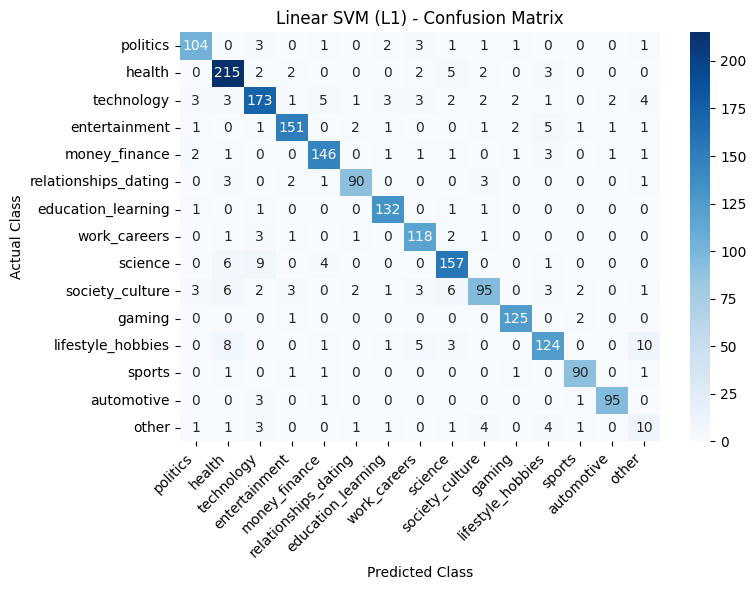


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8673,0.8376,0.8522,117.0000
health,0.8044,0.9437,0.8685,231.0000
technology,0.7672,0.8683,0.8146,205.0000
entertainment,0.9053,0.9162,0.9107,167.0000
money_finance,0.8961,0.8734,0.8846,158.0000
relationships_dating,0.9540,0.8300,0.8877,100.0000
education_learning,0.8993,0.9191,0.9091,136.0000
work_careers,0.8492,0.8425,0.8458,127.0000
science,0.8263,0.8870,0.8556,177.0000
society_culture,0.7748,0.6772,0.7227,127.0000




--- Confusion Matrix ---


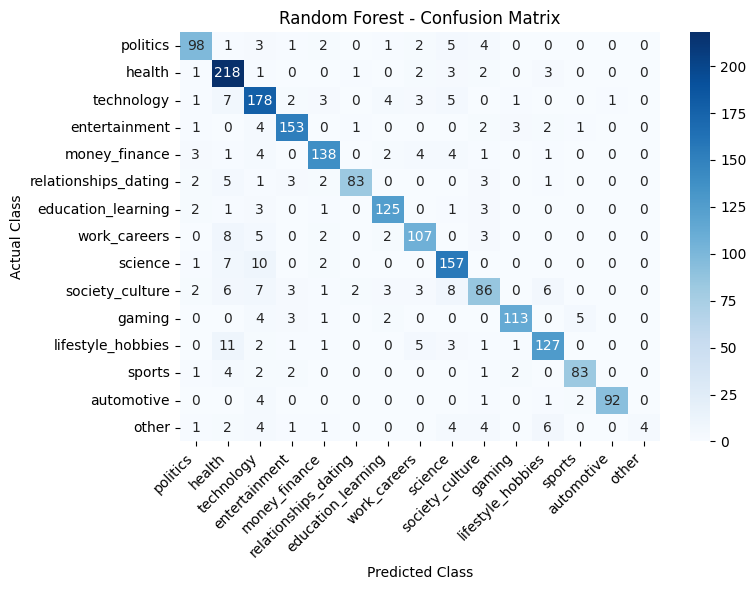


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9107,0.8718,0.8908,117.0000
health,0.8543,0.9134,0.8828,231.0000
technology,0.7716,0.8732,0.8192,205.0000
entertainment,0.8830,0.9042,0.8935,167.0000
money_finance,0.9097,0.8924,0.9010,158.0000
relationships_dating,0.9348,0.8600,0.8958,100.0000
education_learning,0.9412,0.9412,0.9412,136.0000
work_careers,0.8626,0.8898,0.8760,127.0000
science,0.8352,0.8588,0.8468,177.0000
society_culture,0.7561,0.7323,0.7440,127.0000




--- Confusion Matrix ---


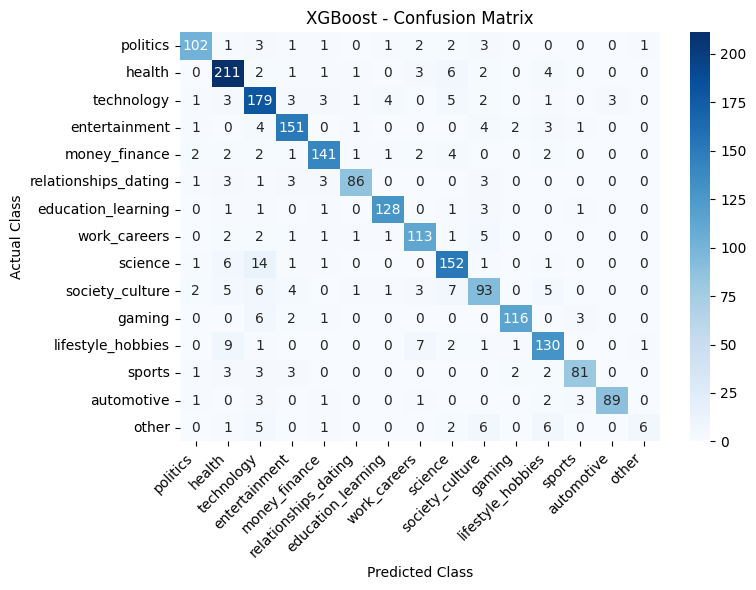

In [51]:
display_model_evaluations(confusion_matrices_embeddings_mean, class_reports_embeddings_mean, topics)

### Embeddings Max

In [52]:
metrics_df_embeddings_max, confusion_matrices_embeddings_max, class_reports_embeddings_max = evaluate_models(
    X_train_embeddings_max, X_test_embeddings_max, y_train_embeddings_max, y_test_embeddings_max, target_names=topics,is_embeddings=True
)

c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [53]:
display(metrics_df_embeddings_max.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
XGBoost,0.875427,0.874682,0.875427,0.872930,0.843744,0.989865
Linear SVM (L2),0.865169,0.866903,0.865169,0.864922,0.836930,0.985380
Linear SVM (L1),0.858329,0.861025,0.858329,0.858681,0.829440,0.984651
Logistic Regression (L2),0.845628,0.854110,0.845628,0.848052,0.822293,0.986323
Logistic Regression (L1),0.834392,0.839630,0.834392,0.836040,0.810563,0.984264
Gaussian Naive Bayes,0.824133,0.839125,0.824133,0.828413,0.804654,0.983095
Random Forest,0.832926,0.831310,0.832926,0.827607,0.786840,0.979734



MODEL: Gaussian Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9010,0.7778,0.8349,117.0000
health,0.8755,0.8831,0.8793,231.0000
technology,0.7739,0.8683,0.8184,205.0000
entertainment,0.8545,0.8443,0.8494,167.0000
money_finance,0.8874,0.8481,0.8673,158.0000
relationships_dating,0.8687,0.8600,0.8643,100.0000
education_learning,0.8872,0.8676,0.8773,136.0000
work_careers,0.8264,0.7874,0.8065,127.0000
science,0.7720,0.8418,0.8054,177.0000
society_culture,0.6742,0.7008,0.6873,127.0000




--- Confusion Matrix ---


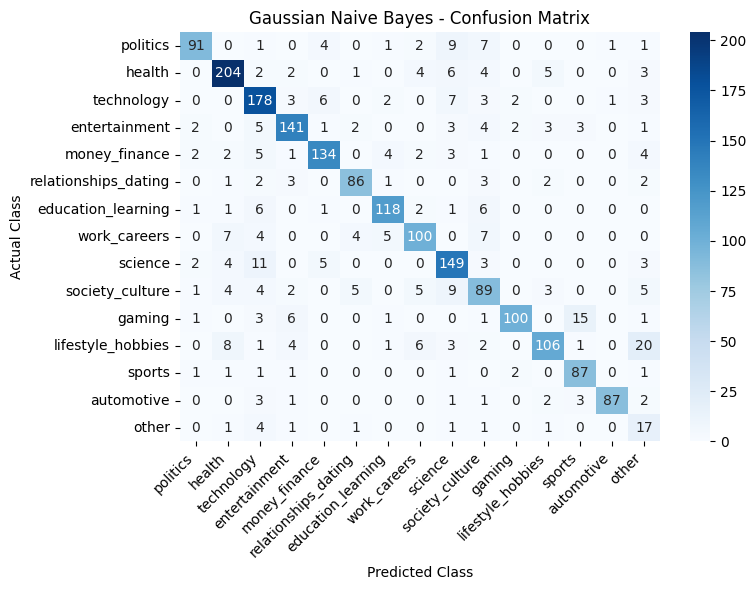


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8761,0.8462,0.8609,117.0000
health,0.8571,0.9091,0.8824,231.0000
technology,0.8148,0.8585,0.8361,205.0000
entertainment,0.8929,0.8982,0.8955,167.0000
money_finance,0.9324,0.8734,0.9020,158.0000
relationships_dating,0.8350,0.8600,0.8473,100.0000
education_learning,0.8750,0.8750,0.8750,136.0000
work_careers,0.8537,0.8268,0.8400,127.0000
science,0.8295,0.8249,0.8272,177.0000
society_culture,0.7500,0.6614,0.7029,127.0000




--- Confusion Matrix ---


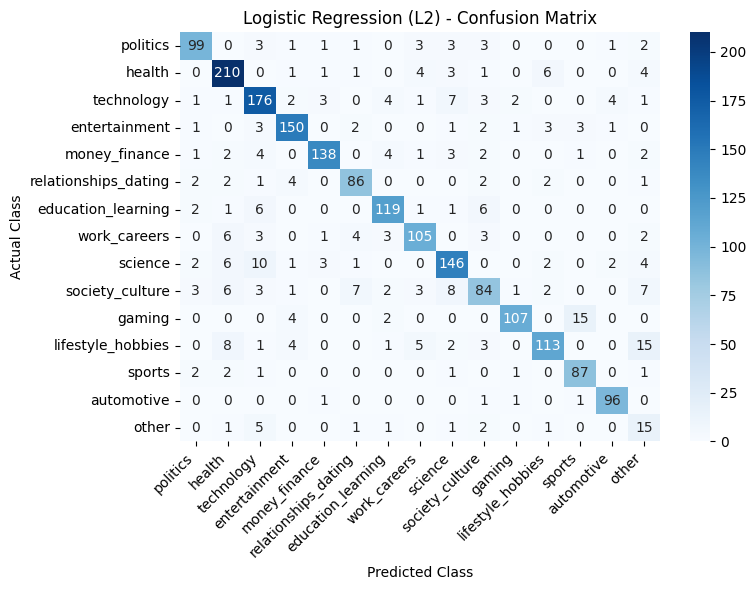


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8596,0.8376,0.8485,117.0000
health,0.8494,0.8788,0.8638,231.0000
technology,0.8057,0.8293,0.8173,205.0000
entertainment,0.9125,0.8743,0.8930,167.0000
money_finance,0.8816,0.8481,0.8645,158.0000
relationships_dating,0.8454,0.8200,0.8325,100.0000
education_learning,0.8676,0.8676,0.8676,136.0000
work_careers,0.7812,0.7874,0.7843,127.0000
science,0.8352,0.8305,0.8329,177.0000
society_culture,0.8087,0.7323,0.7686,127.0000




--- Confusion Matrix ---


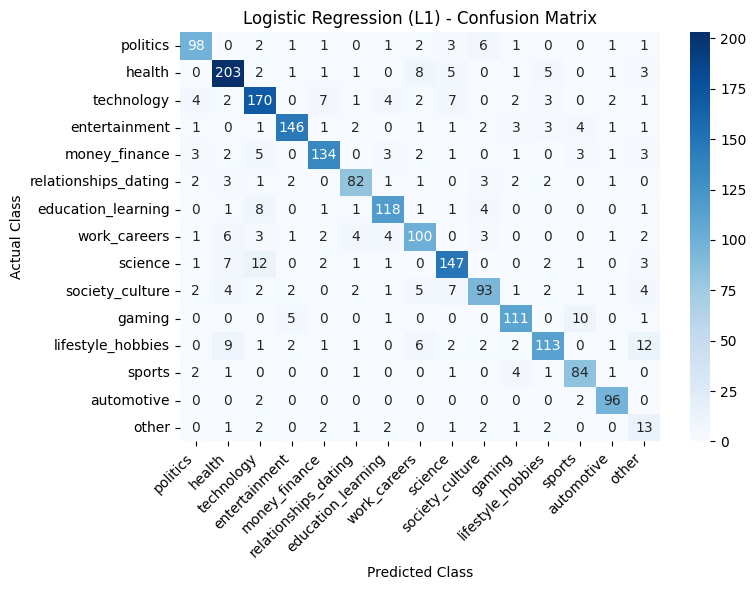


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8870,0.8718,0.8793,117.0000
health,0.8538,0.9351,0.8926,231.0000
technology,0.8458,0.8293,0.8374,205.0000
entertainment,0.9255,0.8922,0.9085,167.0000
money_finance,0.9524,0.8861,0.9180,158.0000
relationships_dating,0.8462,0.8800,0.8627,100.0000
education_learning,0.8750,0.9265,0.9000,136.0000
work_careers,0.8583,0.8583,0.8583,127.0000
science,0.8571,0.8814,0.8691,177.0000
society_culture,0.8056,0.6850,0.7404,127.0000




--- Confusion Matrix ---


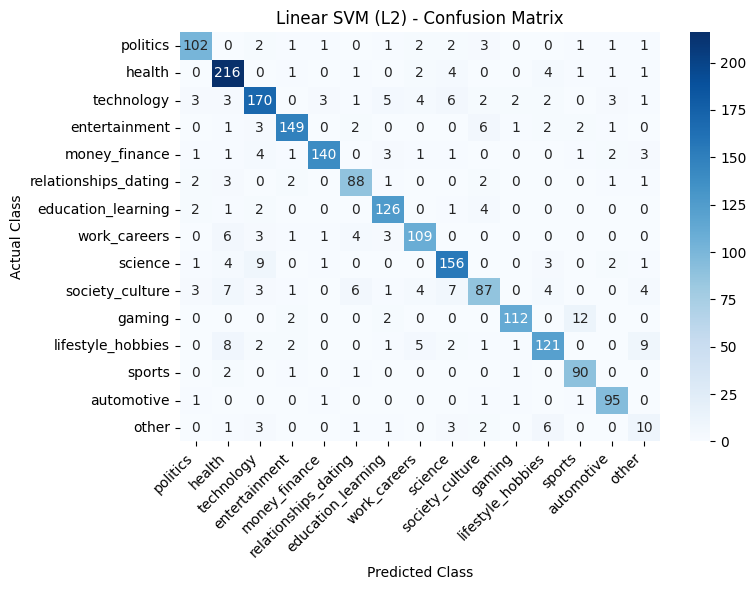


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8947,0.8718,0.8831,117.0000
health,0.8735,0.9264,0.8992,231.0000
technology,0.8227,0.8146,0.8186,205.0000
entertainment,0.9146,0.8982,0.9063,167.0000
money_finance,0.9205,0.8797,0.8997,158.0000
relationships_dating,0.8571,0.8400,0.8485,100.0000
education_learning,0.9000,0.9265,0.9130,136.0000
work_careers,0.8284,0.8740,0.8506,127.0000
science,0.8470,0.8757,0.8611,177.0000
society_culture,0.8155,0.6614,0.7304,127.0000




--- Confusion Matrix ---


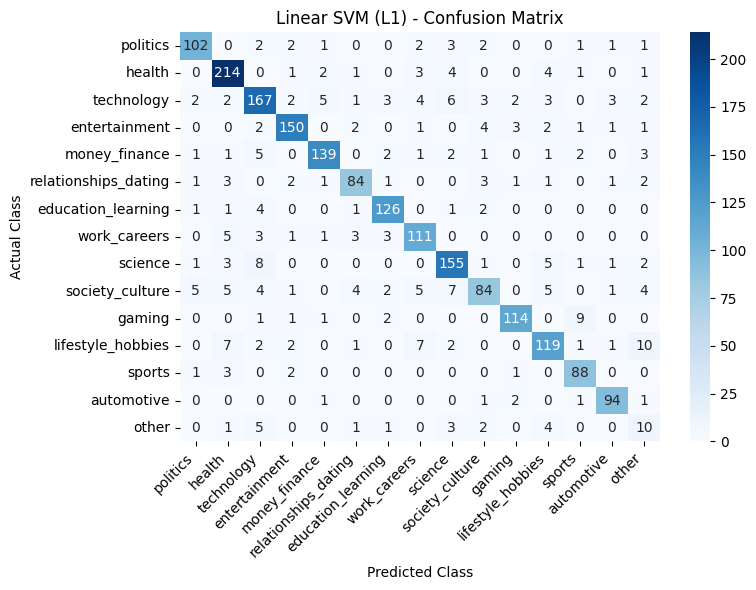


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8532,0.7949,0.8230,117.0000
health,0.8061,0.9177,0.8583,231.0000
technology,0.7739,0.8683,0.8184,205.0000
entertainment,0.8042,0.9102,0.8539,167.0000
money_finance,0.8710,0.8544,0.8626,158.0000
relationships_dating,0.8791,0.8000,0.8377,100.0000
education_learning,0.8593,0.8529,0.8561,136.0000
work_careers,0.8211,0.7953,0.8080,127.0000
science,0.8000,0.8814,0.8387,177.0000
society_culture,0.7358,0.6142,0.6695,127.0000




--- Confusion Matrix ---


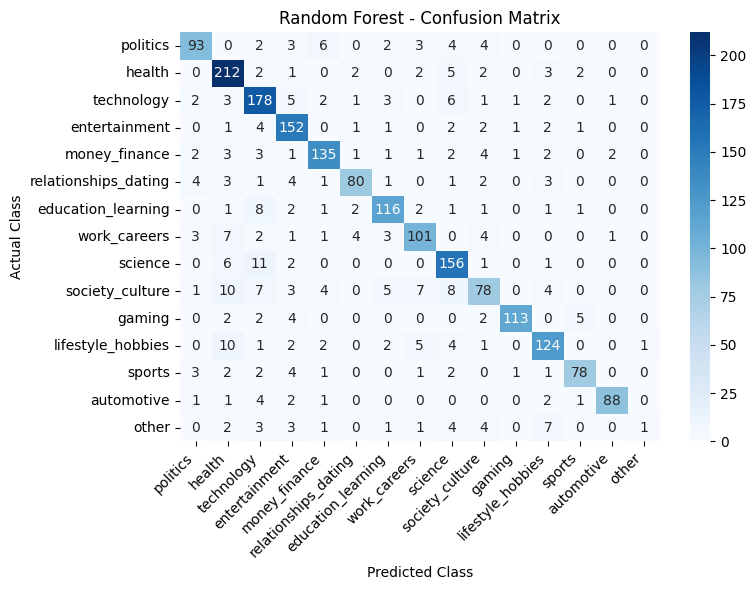


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9352,0.8632,0.8978,117.0000
health,0.8694,0.9221,0.8950,231.0000
technology,0.7863,0.8976,0.8383,205.0000
entertainment,0.9080,0.8862,0.8970,167.0000
money_finance,0.9320,0.8671,0.8984,158.0000
relationships_dating,0.9167,0.8800,0.8980,100.0000
education_learning,0.9313,0.8971,0.9139,136.0000
work_careers,0.8647,0.9055,0.8846,127.0000
science,0.8298,0.8814,0.8548,177.0000
society_culture,0.8103,0.7402,0.7737,127.0000




--- Confusion Matrix ---


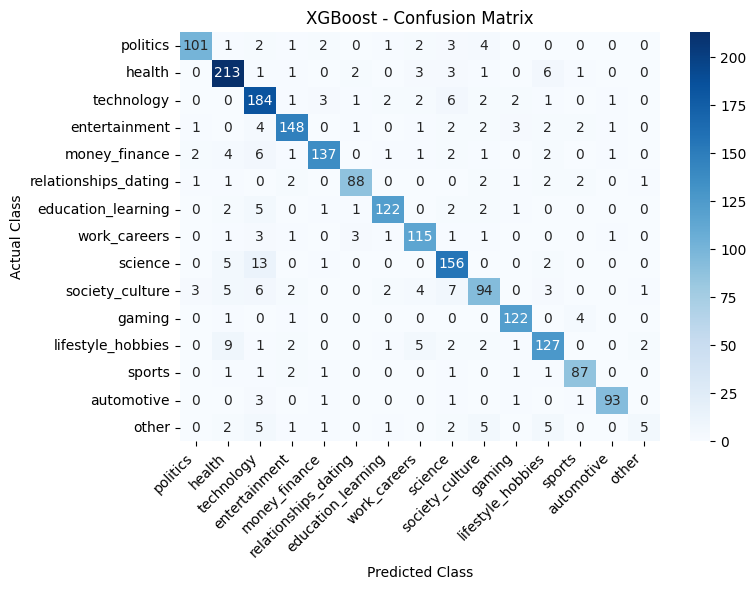

In [54]:
display_model_evaluations(confusion_matrices_embeddings_max, class_reports_embeddings_max, topics)

### Lexicon

In [55]:
metrics_df_empath, confusion_matrices_empath, class_reports_empath = evaluate_models(
    X_train_emp, X_test_emp, y_train_emp, y_test_emp, target_names=topics, is_embeddings=True
)

In [56]:
display(metrics_df_empath.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
XGBoost,0.409380,0.434361,0.409380,0.387524,0.367556,0.824097
Random Forest,0.407426,0.438018,0.407426,0.384843,0.365048,0.817429
Logistic Regression (L1),0.380068,0.361803,0.380068,0.342370,0.327293,0.807830
Logistic Regression (L2),0.380557,0.368322,0.380557,0.342059,0.327131,0.807899
Linear SVM (L1),0.378114,0.336330,0.378114,0.327977,0.316414,0.795825
Linear SVM (L2),0.377626,0.335291,0.377626,0.327375,0.315708,0.796100
Gaussian Naive Bayes,0.356131,0.324795,0.356131,0.303970,0.290179,0.777593



MODEL: Gaussian Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.5368,0.6239,0.5771,117.0000
health,0.6905,0.7532,0.7205,231.0000
technology,0.0000,0.0000,0.0000,205.0000
entertainment,0.1827,0.8323,0.2996,167.0000
money_finance,0.3828,0.3101,0.3427,158.0000
relationships_dating,0.3556,0.1600,0.2207,100.0000
education_learning,0.3472,0.6765,0.4589,136.0000
work_careers,0.4286,0.0945,0.1548,127.0000
science,0.3478,0.1356,0.1951,177.0000
society_culture,0.0909,0.0079,0.0145,127.0000




--- Confusion Matrix ---


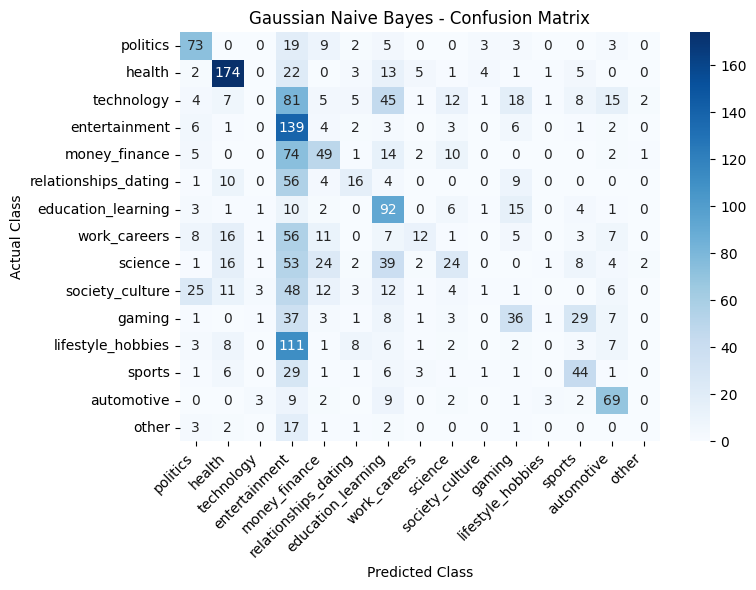


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.5205,0.6496,0.5779,117.0000
health,0.7097,0.7619,0.7349,231.0000
technology,0.4483,0.0634,0.1111,205.0000
entertainment,0.0000,0.0000,0.0000,167.0000
money_finance,0.3788,0.3165,0.3448,158.0000
relationships_dating,0.3556,0.1600,0.2207,100.0000
education_learning,0.4365,0.6324,0.5165,136.0000
work_careers,0.3089,0.4646,0.3711,127.0000
science,0.3909,0.2429,0.2997,177.0000
society_culture,0.0000,0.0000,0.0000,127.0000




--- Confusion Matrix ---


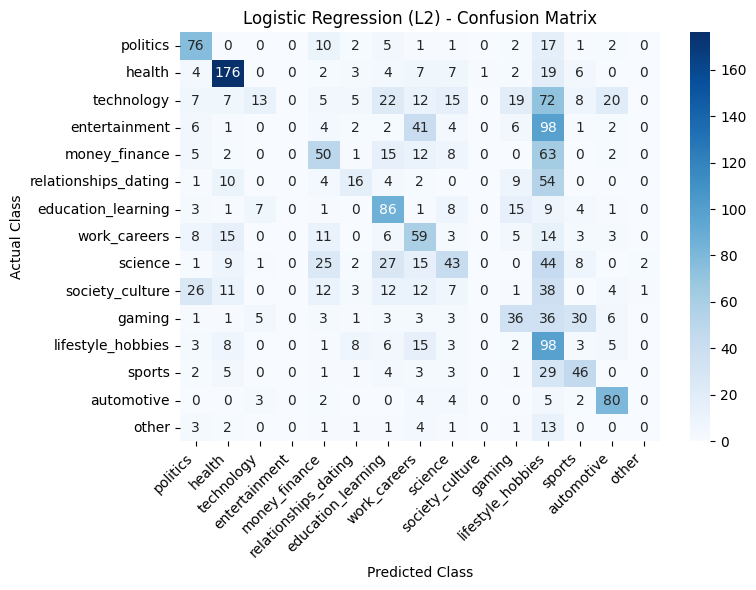


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.5205,0.6496,0.5779,117.0000
health,0.7097,0.7619,0.7349,231.0000
technology,0.3784,0.0683,0.1157,205.0000
entertainment,0.0000,0.0000,0.0000,167.0000
money_finance,0.3906,0.3165,0.3497,158.0000
relationships_dating,0.3556,0.1600,0.2207,100.0000
education_learning,0.4300,0.6324,0.5119,136.0000
work_careers,0.3098,0.4488,0.3666,127.0000
science,0.3874,0.2429,0.2986,177.0000
society_culture,0.0000,0.0000,0.0000,127.0000




--- Confusion Matrix ---


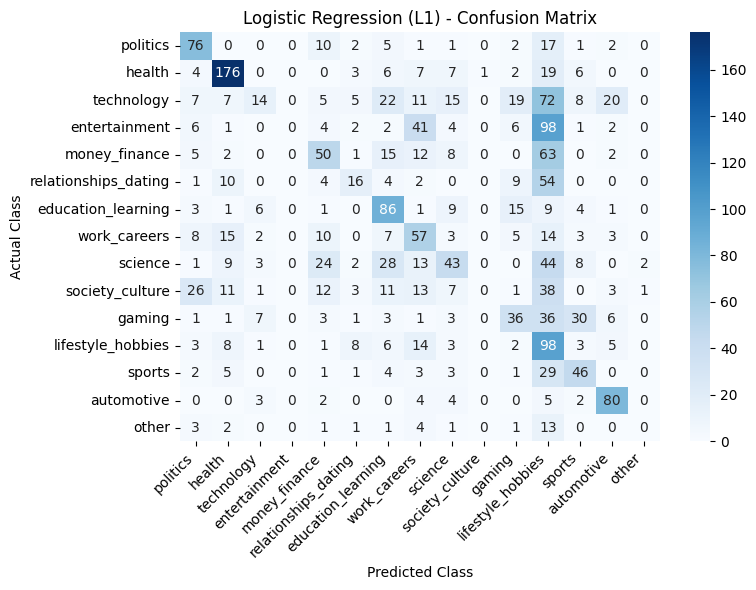


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.4937,0.6667,0.5673,117.0000
health,0.6791,0.7879,0.7295,231.0000
technology,0.0909,0.0049,0.0093,205.0000
entertainment,0.0000,0.0000,0.0000,167.0000
money_finance,0.3839,0.2722,0.3185,158.0000
relationships_dating,0.4167,0.1500,0.2206,100.0000
education_learning,0.3966,0.6765,0.5000,136.0000
work_careers,0.3138,0.4646,0.3746,127.0000
science,0.5000,0.2316,0.3166,177.0000
society_culture,0.0000,0.0000,0.0000,127.0000




--- Confusion Matrix ---


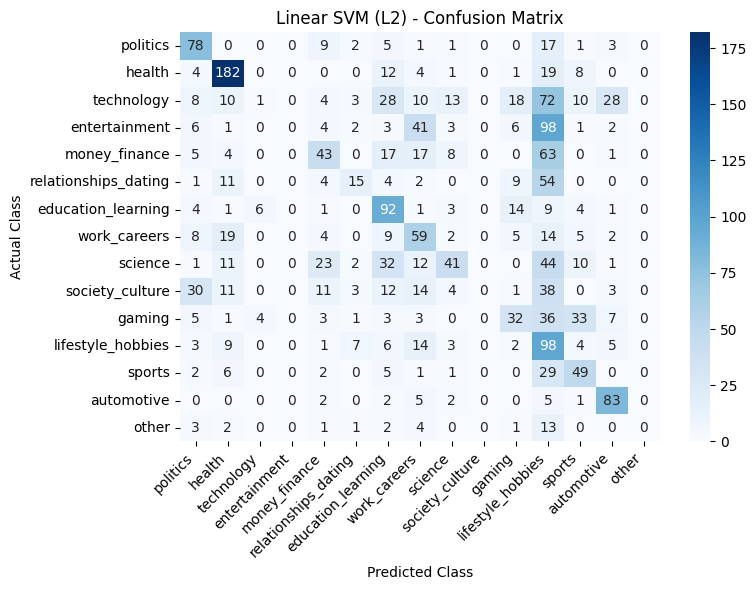


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.4937,0.6667,0.5673,117.0000
health,0.6791,0.7879,0.7295,231.0000
technology,0.0909,0.0049,0.0093,205.0000
entertainment,0.0000,0.0000,0.0000,167.0000
money_finance,0.3945,0.2722,0.3221,158.0000
relationships_dating,0.4167,0.1500,0.2206,100.0000
education_learning,0.3966,0.6765,0.5000,136.0000
work_careers,0.3138,0.4646,0.3746,127.0000
science,0.5000,0.2316,0.3166,177.0000
society_culture,0.0000,0.0000,0.0000,127.0000




--- Confusion Matrix ---


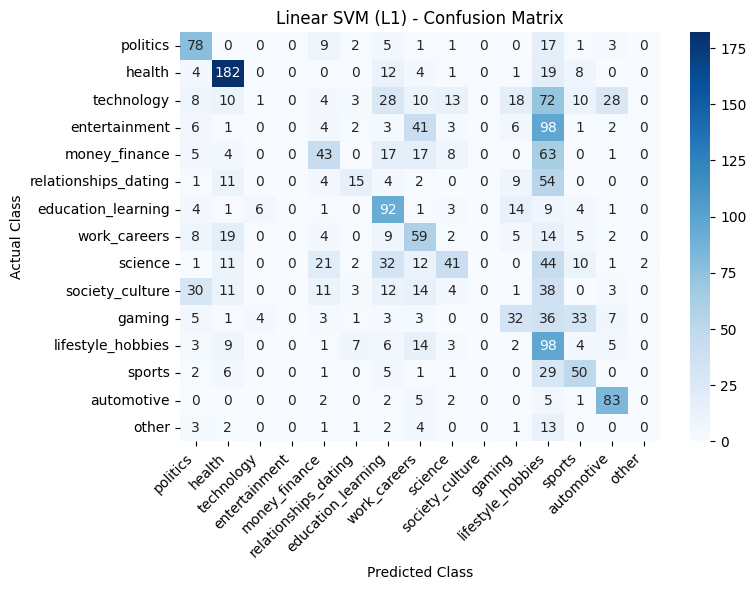


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.5390,0.6496,0.5891,117.0000
health,0.7154,0.7619,0.7379,231.0000
technology,0.5312,0.1659,0.2528,205.0000
entertainment,0.0000,0.0000,0.0000,167.0000
money_finance,0.4044,0.3481,0.3741,158.0000
relationships_dating,0.3387,0.2100,0.2593,100.0000
education_learning,0.5215,0.6250,0.5686,136.0000
work_careers,0.3283,0.5118,0.4000,127.0000
science,0.5747,0.2825,0.3788,177.0000
society_culture,0.4000,0.0472,0.0845,127.0000




--- Confusion Matrix ---


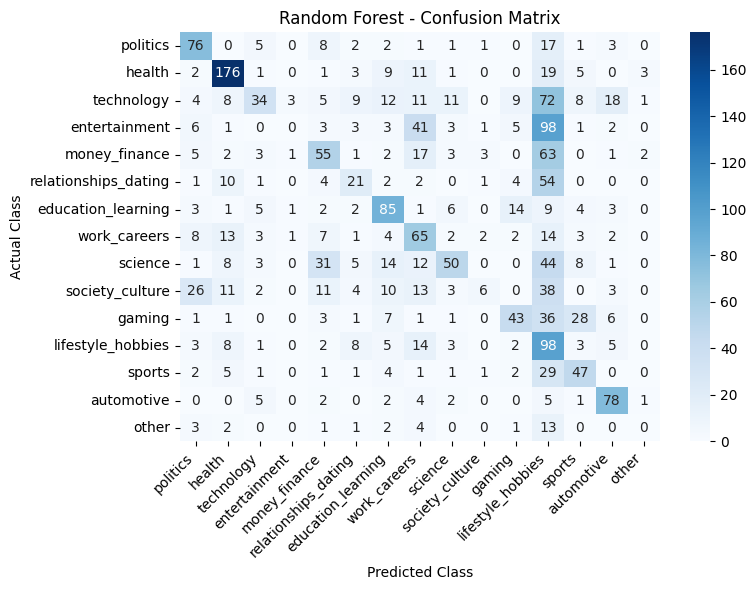


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.5474,0.6410,0.5906,117.0000
health,0.7103,0.7749,0.7412,231.0000
technology,0.4861,0.1707,0.2527,205.0000
entertainment,0.0000,0.0000,0.0000,167.0000
money_finance,0.4938,0.2532,0.3347,158.0000
relationships_dating,0.3818,0.2100,0.2710,100.0000
education_learning,0.6231,0.5956,0.6090,136.0000
work_careers,0.3200,0.5039,0.3914,127.0000
science,0.4078,0.4124,0.4101,177.0000
society_culture,0.4118,0.0551,0.0972,127.0000




--- Confusion Matrix ---


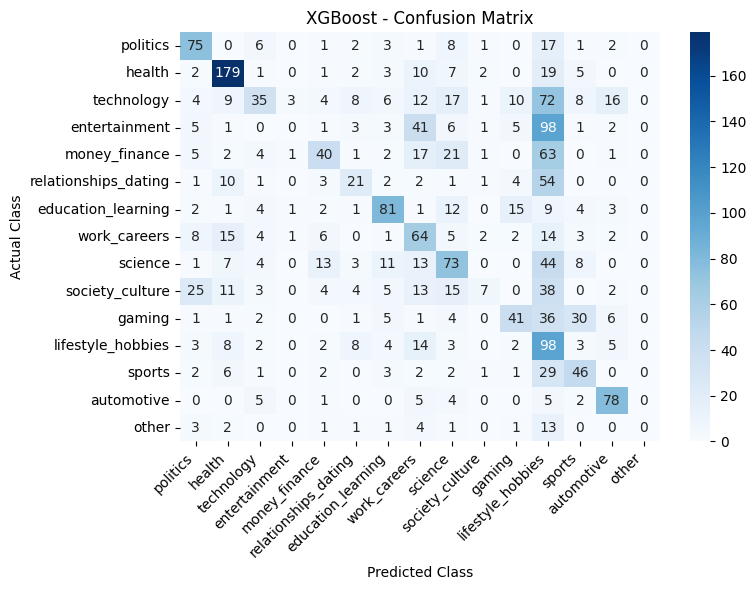

In [57]:
display_model_evaluations(confusion_matrices_empath, class_reports_empath, topics)

### Lexicon + TF-IDF

In [58]:
metrics_df_combined, confusion_matrices_combined, class_reports_combined = evaluate_models(
    X_train_comb, 
    X_test_comb, 
    y_train_emp,     
    y_test_emp,      
    target_names=topics, 
    is_embeddings=False
)

c:\Users\jlsmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [59]:
display(metrics_df_combined.sort_values(by='F1 (macro)', ascending=False))

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L1),0.898388,0.898425,0.898388,0.897785,0.874669,0.989941
Linear SVM (L2),0.900342,0.899076,0.900342,0.899132,0.870853,0.990344
Logistic Regression (L2),0.893991,0.898333,0.893991,0.895470,0.870009,0.993121
XGBoost,0.868100,0.866743,0.868100,0.866441,0.844130,0.988029
Logistic Regression (L1),0.862237,0.872144,0.862237,0.865267,0.843387,0.987867
Random Forest,0.853444,0.857393,0.853444,0.853073,0.828337,0.986275
Multinomial Naive Bayes,0.863214,0.858506,0.863214,0.857079,0.811717,0.989860



MODEL: Multinomial Naive Bayes

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8772,0.8547,0.8658,117.0000
health,0.7619,0.9697,0.8533,231.0000
technology,0.7890,0.9122,0.8462,205.0000
entertainment,0.9325,0.9102,0.9212,167.0000
money_finance,0.9603,0.9177,0.9385,158.0000
relationships_dating,0.9710,0.6700,0.7929,100.0000
education_learning,0.8873,0.9265,0.9065,136.0000
work_careers,0.8770,0.8425,0.8594,127.0000
science,0.8220,0.8870,0.8533,177.0000
society_culture,0.7304,0.6614,0.6942,127.0000




--- Confusion Matrix ---


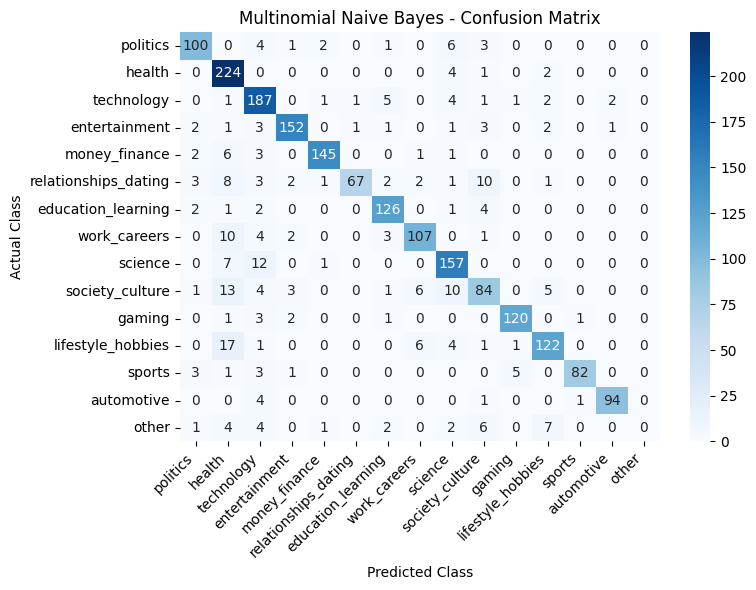


MODEL: Logistic Regression (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9279,0.8803,0.9035,117.000
health,0.9099,0.9177,0.9138,231.000
technology,0.8654,0.8780,0.8717,205.000
entertainment,0.9141,0.8922,0.9030,167.000
money_finance,0.9737,0.9367,0.9548,158.000
relationships_dating,0.9100,0.9100,0.9100,100.000
education_learning,0.9085,0.9485,0.9281,136.000
work_careers,0.8496,0.8898,0.8692,127.000
science,0.8602,0.9040,0.8815,177.000
society_culture,0.8448,0.7717,0.8066,127.000




--- Confusion Matrix ---


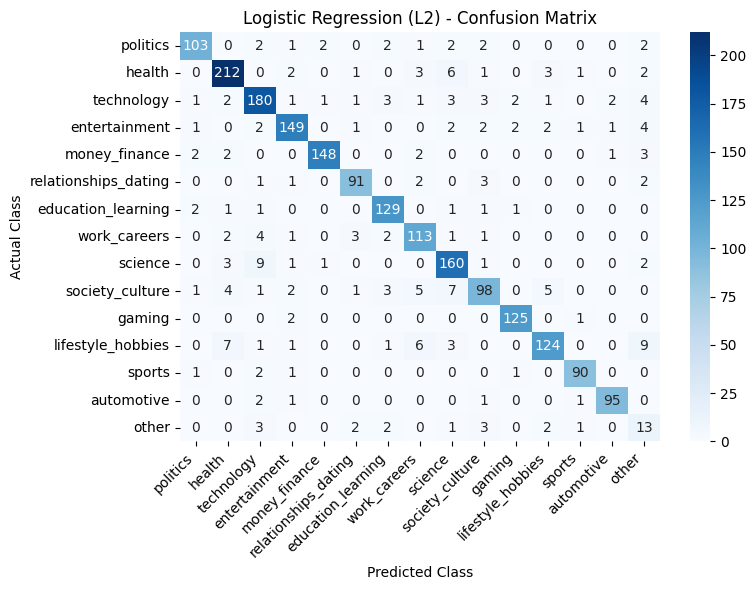


MODEL: Logistic Regression (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9074,0.8376,0.8711,117.0000
health,0.8924,0.8615,0.8767,231.0000
technology,0.8374,0.8293,0.8333,205.0000
entertainment,0.9408,0.8563,0.8966,167.0000
money_finance,0.9539,0.9177,0.9355,158.0000
relationships_dating,0.8700,0.8700,0.8700,100.0000
education_learning,0.9051,0.9118,0.9084,136.0000
work_careers,0.7986,0.8740,0.8346,127.0000
science,0.8862,0.8362,0.8605,177.0000
society_culture,0.6118,0.8189,0.7003,127.0000




--- Confusion Matrix ---


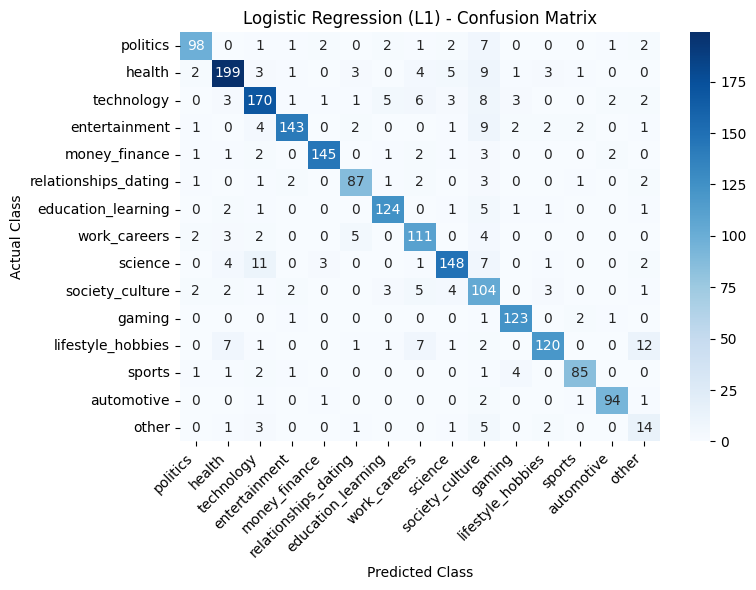


MODEL: Linear SVM (L2)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9035,0.8803,0.8918,117.0000
health,0.8954,0.9264,0.9106,231.0000
technology,0.8738,0.8780,0.8759,205.0000
entertainment,0.9329,0.9162,0.9245,167.0000
money_finance,0.9615,0.9494,0.9554,158.0000
relationships_dating,0.9588,0.9300,0.9442,100.0000
education_learning,0.9291,0.9632,0.9458,136.0000
work_careers,0.8623,0.9370,0.8981,127.0000
science,0.8579,0.8870,0.8722,177.0000
society_culture,0.8393,0.7402,0.7866,127.0000




--- Confusion Matrix ---


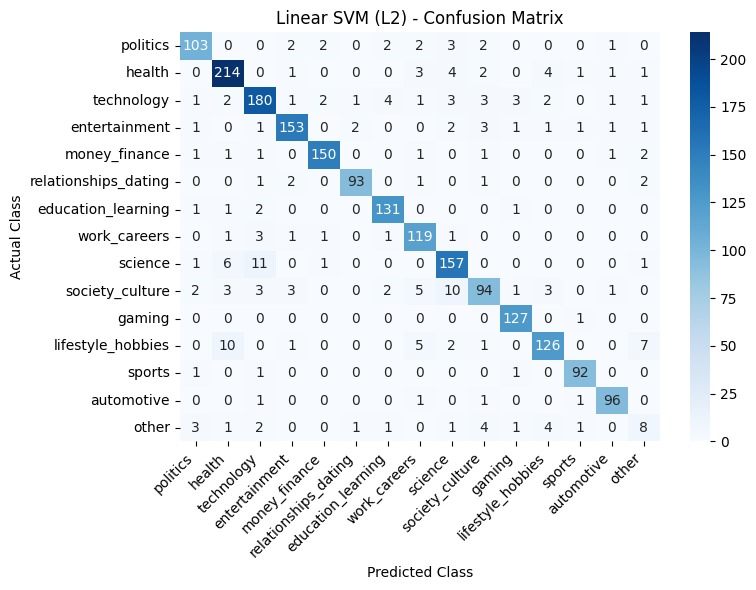


MODEL: Linear SVM (L1)

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.9439,0.8632,0.9018,117.0000
health,0.8792,0.9134,0.8960,231.0000
technology,0.8756,0.8927,0.8841,205.0000
entertainment,0.9107,0.9162,0.9134,167.0000
money_finance,0.9804,0.9494,0.9646,158.0000
relationships_dating,0.9091,0.9000,0.9045,100.0000
education_learning,0.9167,0.9706,0.9429,136.0000
work_careers,0.8478,0.9213,0.8830,127.0000
science,0.8579,0.8870,0.8722,177.0000
society_culture,0.8407,0.7480,0.7917,127.0000




--- Confusion Matrix ---


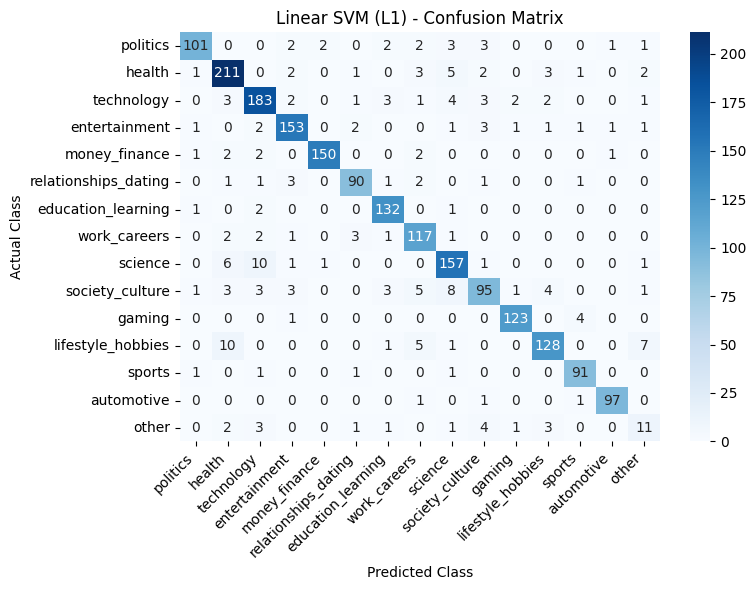


MODEL: Random Forest

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8684,0.8462,0.8571,117.0000
health,0.8287,0.9004,0.8631,231.0000
technology,0.8367,0.8000,0.8180,205.0000
entertainment,0.9290,0.8623,0.8944,167.0000
money_finance,0.9024,0.9367,0.9193,158.0000
relationships_dating,0.8830,0.8300,0.8557,100.0000
education_learning,0.8377,0.9485,0.8897,136.0000
work_careers,0.8129,0.8898,0.8496,127.0000
science,0.7937,0.8475,0.8197,177.0000
society_culture,0.8370,0.6063,0.7032,127.0000




--- Confusion Matrix ---


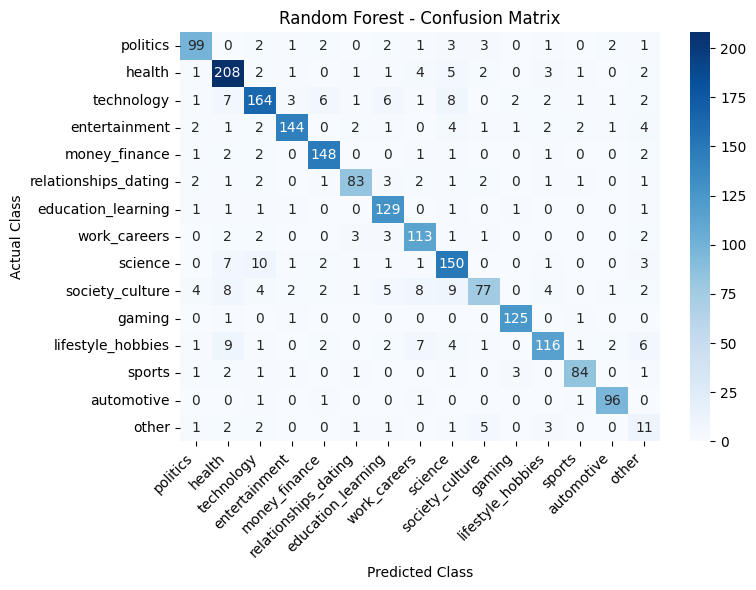


MODEL: XGBoost

--- Classification Report ---


,precision,recall,f1-score,support
politics,0.8991,0.8376,0.8673,117.0000
health,0.8525,0.9004,0.8758,231.0000
technology,0.7883,0.8537,0.8197,205.0000
entertainment,0.9012,0.8743,0.8875,167.0000
money_finance,0.9250,0.9367,0.9308,158.0000
relationships_dating,0.9362,0.8800,0.9072,100.0000
education_learning,0.8836,0.9485,0.9149,136.0000
work_careers,0.8309,0.8898,0.8593,127.0000
science,0.8448,0.8305,0.8376,177.0000
society_culture,0.7652,0.6929,0.7273,127.0000




--- Confusion Matrix ---


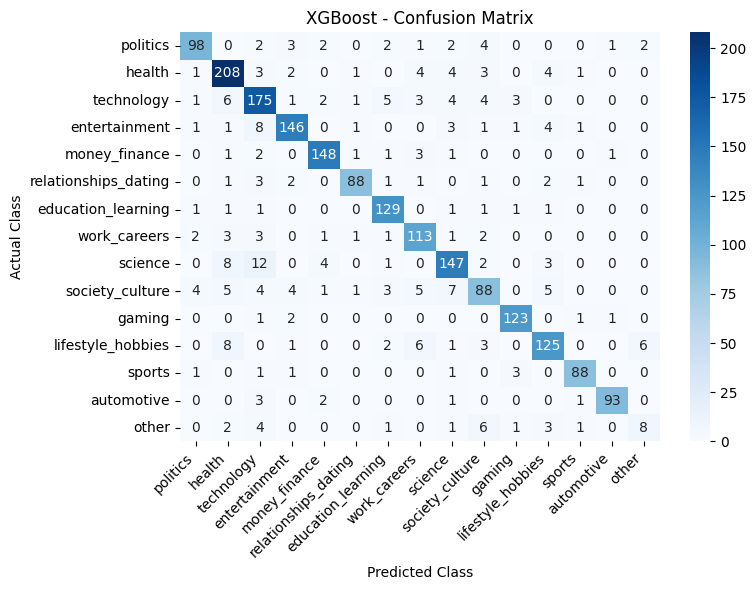

In [60]:
display_model_evaluations(confusion_matrices_combined, class_reports_combined, topics)

## Model & Feature Comparison

To evaluate the different approaches comprehensively, we have concatenated the evaluation metrics for every algorithm across all engineered feature sets into a single, sorted leaderboard.

This consolidated view allows us to answer two critical questions at a glance:
1. **Which feature representation provides the strongest signal?** We can directly compare sparse, frequency-based representations (One-Hot, Bag-of-Words, TF-IDF, N-grams) against dense semantic vectors (Mean and Max Word Embeddings).
2. **Which algorithm best handles the dimensionality of our text data?** We can immediately see whether linear models (Logistic Regression, Linear SVM) or tree-based ensemble methods (Random Forest, XGBoost) outperform our baseline Naive Bayes classifiers.

By sorting this final table by the **Weighted F1-score**, we can mathematically identify the absolute strongest baseline pipelines. This data-driven approach ensures we only spend computational resources on the most promising models during the rigorous Grid Search hyperparameter tuning phase.

In [61]:
metrics_df_onehot.index = metrics_df_onehot.index.astype(str) + ' (One-Hot)'
metrics_df_tfidf.index  = metrics_df_tfidf.index.astype(str) + ' (TF-IDF)'
metrics_df_bow.index    = metrics_df_bow.index.astype(str) + ' (BoW)'
metrics_df_grams.index  = metrics_df_grams.index.astype(str) + ' (grams)'
metrics_df_embeddings_mean.index  = metrics_df_embeddings_mean.index.astype(str) + ' (embeddings mean)'
metrics_df_embeddings_max.index  = metrics_df_embeddings_max.index.astype(str) + ' (embeddings max)'
metrics_df_empath.index  = metrics_df_empath.index.astype(str) + ' (Empath)'
metrics_df_combined.index = metrics_df_combined.index.astype(str) + ' (Combined)'

In [62]:
all_metrics = pd.concat([
    metrics_df_onehot,
    metrics_df_tfidf,
    metrics_df_bow,
    metrics_df_grams,
    metrics_df_embeddings_mean,
    metrics_df_embeddings_max,
    metrics_df_empath,       
    metrics_df_combined
])

all_metrics_sorted = all_metrics.sort_values(by='F1 (weighted)', ascending=False)

display(all_metrics_sorted.head())

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),ROC-AUC (weighted)
Model,,,,,,
Linear SVM (L2) (grams),0.902296,0.901503,0.902296,0.901153,0.881901,0.992071
Linear SVM (L1) (TF-IDF),0.901319,0.900417,0.901319,0.900239,0.876045,0.990092
Linear SVM (L2) (Combined),0.900342,0.899076,0.900342,0.899132,0.870853,0.990344
Linear SVM (L1) (Combined),0.898388,0.898425,0.898388,0.897785,0.874669,0.989941
Linear SVM (L2) (TF-IDF),0.898388,0.896777,0.898388,0.896953,0.868711,0.990464


### Baseline Results & Model Selection

Looking at the consolidated leaderboard, a few massive trends immediately stand out:

**1. The Dominance of Linear SVMs:** The Linear Support Vector Machine algorithm completely swept the top 5 spots. Text classification naturally produces highly dimensional, sparse datasets (thousands of word columns with lots of zeros). The results mathematically prove that Linear SVMs are exceptionally well-suited for drawing geometric boundaries through this specific type of high-dimensional space, vastly outperforming tree-based models (Random Forest/XGBoost) and probabilistic models (Naive Bayes).

**2. The Power of Context, Weighting, and Semantics:** Our advanced feature engineering efforts heavily paid off. 
* **N-grams & TF-IDF:** Capturing multi-word phrases (N-grams) took the #1 overall spot, while mathematically penalizing overly common words (L1 TF-IDF) secured #2. Both provided a significantly stronger learning signal than basic Bag-of-Words or One-Hot encoding. 
* **The Semantic Boost:** Our newly engineered **Combined (TF-IDF + Empath)** representations successfully claimed the #3 and #4 overall spots! This is a massive win, proving that injecting dense, human-curated topical knowledge successfully added highly valuable predictive signals, allowing it to beat the standard L2 TF-IDF baseline. Furthermore, the ROC-AUC scores across all these top models are exceptional (> 0.989), indicating extreme confidence in their probability distributions.

Based on this leaderboard, we will select our absolute **Top 5 configurations** to advance to the exhaustive `GridSearchCV` phase to see if we can squeeze out even more performance:
1. **Linear SVM (L2) - N-grams**
2. **Linear SVM (L1) - TF-IDF**
3. **Linear SVM (L2) - Combined (TF-IDF + Empath)**
4. **Linear SVM (L1) - Combined (TF-IDF + Empath)**
5. **Linear SVM (L2) - TF-IDF**

## Hyperparameter Tuning: Grid Search


In [63]:
top_models_config = {

    'Linear SVM (L2) - N-grams': {
        'model': LinearSVC(max_iter=5000, class_weight='balanced', random_state=42),
        'X_train': X_train_grams,
        'y_train': y_train_grams,
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'loss': ['hinge', 'squared_hinge'],
            'tol': [1e-4, 1e-3]
        }
    },

    'Linear SVM (L1) - TF-IDF': {
        'model': LinearSVC(penalty='l1', dual=False, max_iter=5000, class_weight='balanced', random_state=42),
        'X_train': X_train_tfidf,
        'y_train': y_train_tfidf,
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'tol': [1e-4, 1e-3]
        }
    },

    'Linear SVM (L2) - TF-IDF': {
        'model': LinearSVC(max_iter=5000, class_weight='balanced', random_state=42),
        'X_train': X_train_tfidf,
        'y_train': y_train_tfidf,
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'loss': ['hinge', 'squared_hinge'],
            'tol': [1e-4, 1e-3]
        }
    },

    'Linear SVM (L2) - Combined (TF-IDF + Empath)': {
        'model': LinearSVC(max_iter=5000, class_weight='balanced', random_state=42),
        'X_train': X_train_comb,
        'y_train': y_train_emp, 
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'loss': ['hinge', 'squared_hinge'],
            'tol': [1e-4, 1e-3]
        }
    },

    'Linear SVM (L1) - Combined (TF-IDF + Empath)': {
        'model': LinearSVC(penalty='l1', dual=False, max_iter=5000, class_weight='balanced', random_state=42),
        'X_train': X_train_comb,
        'y_train': y_train_emp, 
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'tol': [1e-4, 1e-3]
        }
    }
}

In [64]:
best_svm_estimators = {}
svm_grid_results = []

print("Starting SVM Grid Search... \n")

for name, config in top_models_config.items():
    print(f"Tuning {name}...")

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['param_grid'],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(config['X_train'], config['y_train'])

    best_svm_estimators[name] = grid.best_estimator_

    svm_grid_results.append({
        'Model Configuration': name,
        'Best F1 Score (5-fold CV)': grid.best_score_,
        'Best Parameters': grid.best_params_
    })

    print(f"Done! Best Params: {grid.best_params_}\n")

Starting SVM Grid Search... 

Tuning Linear SVM (L2) - N-grams...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Done! Best Params: {'C': 1.0, 'loss': 'squared_hinge', 'tol': 0.0001}

Tuning Linear SVM (L1) - TF-IDF...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Done! Best Params: {'C': 1.0, 'tol': 0.001}

Tuning Linear SVM (L2) - TF-IDF...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Done! Best Params: {'C': 0.1, 'loss': 'squared_hinge', 'tol': 0.0001}

Tuning Linear SVM (L2) - Combined (TF-IDF + Empath)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Done! Best Params: {'C': 1.0, 'loss': 'squared_hinge', 'tol': 0.001}

Tuning Linear SVM (L1) - Combined (TF-IDF + Empath)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Done! Best Params: {'C': 1.0, 'tol': 0.001}



In [65]:
svm_tuning_df = pd.DataFrame(svm_grid_results).sort_values(by='Best F1 Score (5-fold CV)', ascending=False)
display(svm_tuning_df)

,Model Configuration,Best F1 Score (5-fold CV),Best Parameters
0,Linear SVM (L2) - N-grams,0.894437,"{'C': 1.0, 'loss': 'squared_hinge', 'tol': 0.0..."
2,Linear SVM (L2) - TF-IDF,0.893958,"{'C': 0.1, 'loss': 'squared_hinge', 'tol': 0.0..."
3,Linear SVM (L2) - Combined (TF-IDF + Empath),0.892983,"{'C': 1.0, 'loss': 'squared_hinge', 'tol': 0.001}"
4,Linear SVM (L1) - Combined (TF-IDF + Empath),0.887401,"{'C': 1.0, 'tol': 0.001}"
1,Linear SVM (L1) - TF-IDF,0.886433,"{'C': 1.0, 'tol': 0.001}"


### Grid Search and Cross-Validation Results

The results from the 5-fold cross-validation (`GridSearchCV`) show an incredibly tight race between our top four model configurations, highlighting the overall stability of Linear SVMs for this dataset:

* **The Top Performer:** The **Linear SVM (L2) with N-grams** achieved the highest cross-validated F1-score (**0.8944**). Interestingly, the grid search selected `C=1.0` and `loss='squared_hinge'`, indicating that the default parameters were already the mathematical optimum for the N-gram feature set.
* **Strong Regularization for L2 TF-IDF:** The **Linear SVM (L2) with TF-IDF** came in a microscopic second place (**0.8939**). For this configuration, the grid search selected `C=0.1`, applying stronger regularization to draw a smoother, more generalized boundary through the TF-IDF matrix to prevent overfitting.
* **The Semantic Hybrid:** The **Linear SVM (L2) with the Combined Feature Space (TF-IDF + Empath)** secured a remarkably close third place (**0.8929**). With the grid search settling on `C=1.0` and `loss='squared_hinge'`, this proves that injecting dense, human-curated topical knowledge alongside sparse frequencies maintains excellent mathematical stability and highly competitive performance during strict cross-validation.
* **The L1 Semantic Hybrid:** The newly introduced **Linear SVM (L1) with the Combined Feature Space (TF-IDF + Empath)** claimed fourth place (**0.8874**). With `C=1.0`, this configuration notably outperformed the standard L1 TF-IDF model. This is a fascinating result: it shows that when the L1 penalty aggressively prunes away noisy text features, the dense Empath semantic features survive the cut, providing a measurably stronger learning signal than pure word frequencies alone.
* **The L1 Feature Selector:** The **Linear SVM (L1) with TF-IDF** scored slightly lower during the strict CV phase (**0.8864**). However, because the L1 penalty acts as a strict feature selector (pushing noisy word weights to zero), it tends to be slightly more conservative during cross-validation, often leading to excellent generalization on unseen data later.

**Conclusion:** With the optimal hyperparameters mathematically locked in, the cross-validation proves that all five models are highly stable. We can now push these optimized models forward to the final evaluation on our unseen test set.

In [66]:
final_metrics_data = []

model_results = {}

print("--- FINAL TEST SET SCORES (Grid Search Winners) ---\n")

for model_name, tuned_model in best_svm_estimators.items():

    if "N-grams" in model_name:
        X_test_current = X_test_grams
        y_test_current = y_test_grams

    elif "Combined" in model_name: 
        X_test_current = X_test_comb
        y_test_current = y_test_emp

    elif "TF-IDF" in model_name:
        X_test_current = X_test_tfidf
        y_test_current = y_test_tfidf

    y_pred = tuned_model.predict(X_test_current)
    y_scores_raw = tuned_model.decision_function(X_test_current)
    y_scores_prob = softmax(y_scores_raw, axis=1)

    acc = accuracy_score(y_test_current, y_pred)
    prec = precision_score(y_test_current, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_current, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_current, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test_current, y_scores_prob, multi_class='ovr', average='weighted')

    final_metrics_data.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision (Weighted)': prec,
        'Recall (Weighted)': rec,
        'F1 Score (Weighted)': f1,
        'ROC-AUC (Weighted)': roc_auc
    })

    model_results[model_name] = {
        'y_test': y_test_current,
        'y_pred': y_pred
    }

final_metrics_df = pd.DataFrame(final_metrics_data).set_index('Model')
sorted_metrics_df = final_metrics_df.sort_values(by='F1 Score (Weighted)', ascending=False)

display(sorted_metrics_df)

--- FINAL TEST SET SCORES (Grid Search Winners) ---



,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted),ROC-AUC (Weighted)
Model,,,,,
Linear SVM (L1) - TF-IDF,0.902296,0.901700,0.902296,0.901349,0.990084
Linear SVM (L2) - N-grams,0.902296,0.901503,0.902296,0.901153,0.992071
Linear SVM (L2) - Combined (TF-IDF + Empath),0.899853,0.898672,0.899853,0.898665,0.990353
Linear SVM (L1) - Combined (TF-IDF + Empath),0.898388,0.898425,0.898388,0.897785,0.989942
Linear SVM (L2) - TF-IDF,0.894968,0.896386,0.894968,0.894663,0.991239


### Top Models Final Performance Analysis

Looking at the final test metrics across our five optimized configurations, the results are extraordinarily close, revealing a few key insights about our text representations, feature engineering, and regularization strategies:

* **The Ultimate Tiebreaker:** Both the **Linear SVM (L1) with TF-IDF** and the **Linear SVM (L2) with N-grams** achieved the exact same overall Accuracy (**0.9022**). However, the L1/TF-IDF combination edged out the win by a microscopic margin in the Weighted F1-Score (**0.9013** vs **0.9011**), proving it is slightly better at handling the imbalanced minority classes.
* **The Semantic Boost (Empath Lexicon):** Both of our engineered **Combined (TF-IDF + Empath)** models successfully outperformed the standard L2 TF-IDF baseline (**0.8946** F1-score). The L2 Combined scored **0.8986**, and the L1 Combined closely followed at **0.8977**. This is a significant finding: it proves that regardless of the regularization technique used, injecting dense, human-curated topical knowledge successfully adds a highly valuable semantic signal. 
* **The Regularization Tug-of-War (L1 vs L2):** Comparing the models reveals a fascinating mathematical dynamic. For the pure, thousands-of-columns-wide TF-IDF matrix, the aggressive feature-pruning of the **L1** penalty was the absolute best approach (pushing noisy words to exactly `0`). However, for the Combined feature space, the **L2** penalty actually performed better than the L1. This makes perfect sense: L2 is much better at smoothly distributing weights across mixed representations (sparse words + dense Empath categories) without zeroing out important context.
* **The ROC-AUC Silver Lining:** Interestingly, while the L1 model won the hard classifications (Accuracy/F1), the L2 N-grams model actually achieved a slightly higher ROC-AUC (**0.9920** vs **0.9900**). This indicates that capturing multi-word phrases (N-grams) gave the model slightly better underlying confidence in its probability distributions, even if the L1 model ultimately drew slightly better hard decision boundaries.

**Conclusion:** The differences between the top configurations are fractions of a percent, proving that our baseline representations, N-grams, and external semantic lexicons are all highly effective. Moving forward, we proceed with the **Linear SVM (L1) - TF-IDF** as our final champion model due to its superior Precision, F1-score, and aggressive feature-pruning capabilities!

In [67]:
best_model_name = sorted_metrics_df.index[0]

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*70}\n")

best_y_test = model_results[best_model_name]['y_test']
best_y_pred = model_results[best_model_name]['y_pred']


BEST MODEL: Linear SVM (L1) - TF-IDF



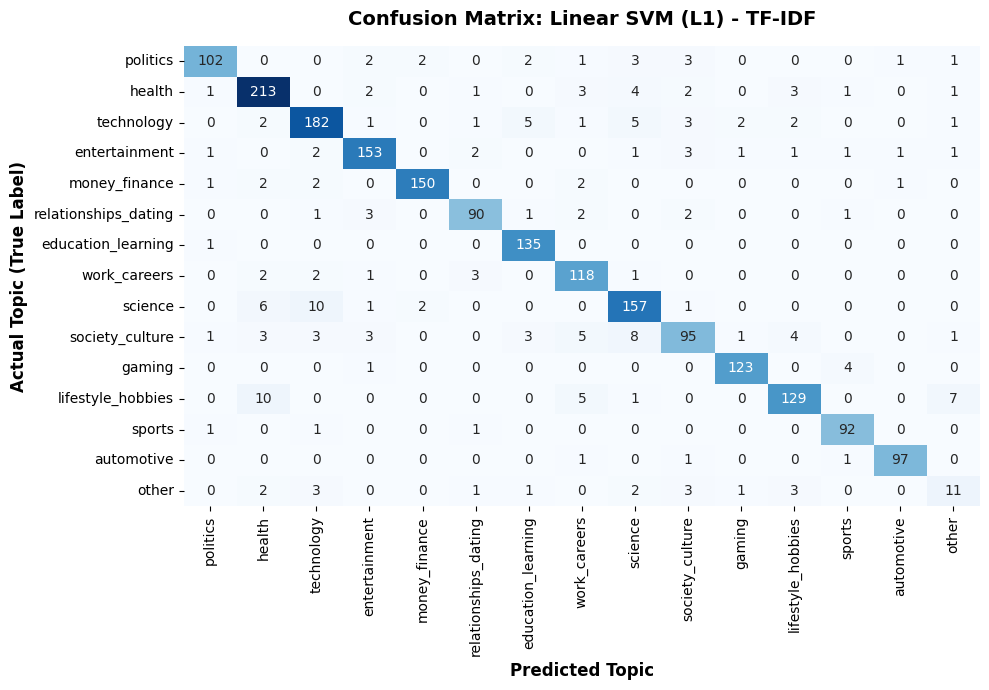

In [68]:
cm = confusion_matrix(best_y_test, best_y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=topics, yticklabels=topics)

plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Topic (True Label)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Topic', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

While the Linear SVM (L1) with TF-IDF achieved excellent overall performance, evidenced by the strong dark diagonal of true positives, an analysis of the off-diagonal errors reveals the inherent limitations of lexical (word-count) feature representations.

The most notable misclassifications stem from three specific NLP challenges:

**1. Highly Overlapping Domains**
The model frequently confused closely related topics, specifically predicting 'Science' as 'Technology' (10 instances) and 'Lifestyle/Hobbies' as 'Health' (10 instances). Because TF-IDF relies on exact word frequencies rather than deep semantic context, articles containing shared vocabulary (e.g., "fitness," "research," "software," "data") create fuzzy mathematical decision boundaries.

**2. Abstract and Broad Categories**
This fuzziness also heavily impacted abstract categories like **Society & Culture**. Because "society" is a notoriously broad topic, its vocabulary is highly generalized. The confusion matrix visualizes this clearly, showing 8 instances of 'Society & Culture' being misclassified as 'Science'. The SVM struggles to draw a distinct hyperplane when the language is this conceptual and naturally overlaps with sociological or scientific research.

**3. The 'Other' Category Scattering**
Visually, the weakest point on the diagonal belongs to the **'Other'** category. Because this class acts as a miscellaneous "junk drawer" for articles that do not fit anywhere else, it lacks a cohesive, unifying vocabulary. The matrix illustrates this perfectly as a dispersed "shotgun" effect: true 'Other' articles are scattered across almost every single column (misclassified as Technology, Society & Culture, and Lifestyle/Hobbies). Conversely, the model erroneously dumped 7 'Lifestyle/Hobbies' articles into the 'Other' column, proving the algorithm struggles to find a consistent mathematical pattern without a distinct vocabulary.

**Conclusion**
These logical misclassifications highlight the ceiling of traditional machine learning approaches. While TF-IDF and Linear SVMs are exceptionally robust for distinct, well-defined domains, their reliance on raw word counts naturally loses effectiveness when dealing with abstract concepts, shared vocabularies, or catch-all categories. Future improvements to solve these semantic overlaps would require contextual Deep Learning models, such as Transformers, to capture nuanced human intent.

In [69]:
report_dict = classification_report(best_y_test, best_y_pred, target_names=topics, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

print("Classification Report:")
display(report_df.round(4))

Classification Report:


,precision,recall,f1-score,support
politics,0.9444,0.8718,0.9067,117.0000
health,0.8875,0.9221,0.9045,231.0000
technology,0.8835,0.8878,0.8856,205.0000
entertainment,0.9162,0.9162,0.9162,167.0000
money_finance,0.9740,0.9494,0.9615,158.0000
relationships_dating,0.9091,0.9000,0.9045,100.0000
education_learning,0.9184,0.9926,0.9541,136.0000
work_careers,0.8551,0.9291,0.8906,127.0000
science,0.8626,0.8870,0.8747,177.0000
society_culture,0.8407,0.7480,0.7917,127.0000


### Classification Report Analysis

An analysis of the Classification Report for the champion model (Linear SVM with L1 penalty and TF-IDF features) yields a highly impressive weighted F1-score of **0.9013**. Breaking down the performance class by class reveals a clear pattern based on lexical distinctiveness:

**1. High-Performing Niche Categories (F1 > 0.95)**
The model achieved its highest scores in categories like **Automotive (0.9700)**, **Money & Finance (0.9615)**, and **Gaming (0.9609)**. These domains possess highly specialized and exclusive vocabularies (e.g., "engine," "stock," "console"). TF-IDF excels here because the presence of these unique keywords provides incredibly strong, unambiguous signals for the SVM hyperplanes.

**2. The Struggle with Abstract and Broad Categories**
Conversely, the model saw a noticeable drop in performance for **Society & Culture (0.7917)**. This is a notoriously broad and abstract topic. Articles discussing 'society' heavily overlap with Politics, Health, and Lifestyle. Because the vocabulary is highly generalized, the SVM struggles to find distinct mathematical boundaries, leading to lower recall (**0.7480**) as these articles get misclassified into more specific overlapping domains.

**3. The 'Other' Category Phenomenon**
The lowest performing class by far is **'Other' (0.4400 F1-score)**. This is an expected and completely normal limitation of traditional NLP. Because 'Other' acts as a miscellaneous "junk drawer" for articles that don't fit anywhere else, it lacks a cohesive, unifying vocabulary. Consequently, TF-IDF cannot extract a reliable mathematical pattern. Furthermore, with a support of only 27 samples, it severely lacks the data density required for the algorithm to learn meaningful weights.

**Conclusion**
Overall, the classification report confirms that the Linear SVM pipeline is exceptionally robust for distinct, well-defined domains. The primary drops in F1-score are logically isolated to abstract or catch-all categories where word-count matrices naturally lose contextual meaning.

## Project Conclusion

In this project, we successfully built, optimized, and evaluated a multiclass Natural Language Processing (NLP) classifier using strictly traditional machine learning techniques. By systematically testing diverse feature representations, ranging from sparse frequency matrices (Bag-of-Words, TF-IDF, N-grams) to dense semantic vectors (Word Embeddings), we identified the optimal mathematical approach for categorizing highly dimensional text data.

**Key Insights & Achievements:**
1. **The Winning Pipeline:** The **Linear SVM with L1 regularization and TF-IDF features** emerged as the most robust model, achieving a highly impressive Weighted F1-score of **0.9013** and an Accuracy of **0.9022**.
2. **The Power of Feature Selection:** The microscopic victory of the L1 penalty over the L2 penalty highlighted a crucial NLP concept: because TF-IDF matrices contain thousands of sparse word columns, the L1 penalty's ability to act as an aggressive feature selector (pushing noisy, uninformative word weights to exactly zero) is incredibly effective at preventing overfitting.
3. **N-grams vs. Embeddings:** While dense Word Embeddings are popular, our baseline leaderboard proved that capturing specific multi-word phrases (N-grams) and mathematically penalizing common words (TF-IDF) provided a significantly stronger learning signal for linear models than basic Mean/Max pooled embeddings.

**Limitations and Future Work:**
* **Dataset Constraints & Class Imbalance:** The overall dataset size is relatively small (approximately 10,000 total samples) and exhibits noticeable class imbalance. While majority classes like 'Health' (1,157 samples) and 'Technology' (1,023) provided rich vocabularies for the model to train on, minority classes like 'Sports' (475) and the catch-all 'Other' category (134) severely lacked the data density required for the algorithm to learn reliable weights. Future iterations would benefit immensely from gathering more data for these underrepresented labels.
* **Semantic Overlap & Lexical Limits:** Despite the excellent overall performance, our deep-dive error analysis revealed the strict ceiling of traditional lexical machine learning. The model's primary misclassifications occurred between highly overlapping, abstract topics (e.g., confusing 'Science' with 'Technology', or struggling with 'Society & Culture'). Because TF-IDF relies entirely on exact word frequencies, it inherently lacks deep semantic understanding and struggles when distinct categories share identical vocabularies.

**Final Verdict:**
We have maximized the potential of traditional machine learning for this dataset. To break past this ~90% performance ceiling and solve the remaining semantic overlaps, future work should involve expanding the dataset to balance the minority classes and exploring Deep Learning architectures, specifically transformer-based models, which are capable of reading full sentences to capture deep, nuanced human context.